# 机器学习课程大作业   2026年5月

- From 合肥工业大学宣城校区 计算机与信息学院 电子信息科学与技术专业
- 作者：
  宋江琦 | 戴婧婕 | 张子哲 | 张诗雨 | 彭湃

## 摘要

本项目基于 Kaggle 威斯康星乳腺癌诊断数据集（WBCD），系统探索了多种机器学习与深度学习方法在肿瘤良恶性二分类任务中的应用效果。数据集共包含 569 个样本和 30 个由细胞核图像计算得出的数值特征，分类目标为判断肿瘤是恶性（Malignant）还是良性（Benign）。

在本项目中，我们依次尝试并实现了五种主流分类方法：逻辑回归（Logistic Regression）、支持向量机（SVM）、随机森林（Random Forest）、全连接神经网络（FCNN）以及梯度提升树（XGBoost）。每种方法均遵循统一的实验流程：数据清洗与预处理、特征标准化、模型训练与调优、以及基于准确率、精确率、召回率和 F1 分数的综合评估。

通过横向对比，我们分析了各类模型在该结构化医疗数据集上的表现差异，并就特征压缩对模型性能的影响进行了专项对比实验，为实际的临床辅助诊断场景提供了方法层面的参考与借鉴。

## 1.1 项目背景

乳腺癌是全球女性发病率最高的恶性肿瘤之一。据世界卫生组织数据，每年新增病例超过 200 万，早期发现与准确诊断对患者的预后至关重要。传统的病理诊断依赖医生对活检切片的人工判读，不仅耗时费力，还受主观经验的影响，存在一定的误诊风险。随着医学成像技术的发展，通过对细胞核形态的数字化特征提取，利用机器学习模型辅助诊断已成为一个重要的研究方向。

本项目使用的数据集为 **威斯康星乳腺癌诊断数据集（Wisconsin Breast Cancer Diagnostic Dataset, WBCD）**，由威斯康星大学医学院收集，最初发布于 UCI 机器学习库，现已成为医疗分类任务的标准基准数据集之一，同时可通过 Kaggle 平台获取。

**数据集基本信息：**
- 样本总数：**569 条**，其中良性（Benign）357 条，恶性（Malignant）212 条，良恶性比约为 **6:4**，类别分布相对均衡，无需进行过采样或欠采样处理。
- 特征数量：**30 个**数值型特征，均从细胞核的数字化图像中计算得出。
- 标签列：`diagnosis`，原始为字符串格式（`M` 表示恶性，`B` 表示良性），本项目将其映射为整型（`M→1`，`B→0`）。

**30 个特征的来源与含义：**

数据集针对每个细胞核图像，分别从以下 **10 种基础物理量**中提取指标：

| 物理属性 | 含义说明 |
|---|---|
| radius（半径） | 细胞核中心到边界各点距离的均值 |
| texture（纹理） | 灰度值的标准差，反映内部复杂程度 |
| perimeter（周长） | 细胞核边界的总长度 |
| area（面积） | 细胞核的像素面积 |
| smoothness（平滑度） | 局部半径变化率，数值越大边界越不规则 |
| compactness（紧凑度） | 周长²/面积 - 1，圆形时为最小值 |
| concavity（凹度） | 轮廓凹入部分的严重程度 |
| concave points（凹点数） | 轮廓凹入部分的个数 |
| symmetry（对称性） | 细胞核形状的左右对称程度 |
| fractal dimension（分形维度） | 边界的自相似程度，数值越高边界越粗糙 |

对每一种物理量，数据集进一步计算了三类统计量：**均值（mean）、标准误差（standard error, se）、极值（worst）**，共 10×3 = 30 个特征。

**数据分布特点：**

不同特征之间的数值量纲差异极大。例如，`area_mean`（面积均值）的数值范围大约在 143 到 2501 之间，而 `smoothness_mean`（平滑度均值）的数值范围仅在 0.05 到 0.16 之间——两者相差近四个数量级。这种量纲不一致性对依赖距离计算或梯度下降的模型（如 SVM、逻辑回归、神经网络）会造成严重干扰，因此在模型训练之前必须进行特征标准化处理（Z-score Normalization），将所有特征缩放到均值为 0、标准差为 1 的统一尺度，为后续建模奠定基础。

## 1.2 项目目标

本项目的核心目标是：**基于乳腺癌细胞核的形态学数值特征，构建并比较多种机器学习与深度学习分类模型，自动判断肿瘤的良恶性，为临床医生提供辅助诊断参考。**

从技术层面来看，这是一个典型的**监督学习二分类问题（Binary Classification）**：输入为 30 维数值特征向量，输出为 `0`（良性）或 `1`（恶性）的预测标签。

在实际临床意义上，这项工作的价值体现在以下几个方面：

**1. 提升诊断效率：** 传统病理诊断需要由经验丰富的病理科医生对活检切片进行逐一分析，流程耗时长、人力成本高。基于机器学习的自动化分类系统能够在秒级时间内完成预测，大幅缩短诊断周期，尤其适合医疗资源相对匮乏的基层医院或偏远地区。

**2. 降低漏诊风险：** 恶性肿瘤的漏诊（即将真实恶性判为良性）在临床上代价极高，可能导致患者错失最佳治疗窗口。机器学习模型作为"第二意见"，可以对高风险样本进行标记和预警，辅助医生重点复核，从而降低人为疏漏的概率。

**3. 探索特征对分类的贡献：** 通过训练可解释性强的模型（如逻辑回归、随机森林），我们可以量化各个细胞核特征对分类结果的重要程度，从而反哺医学研究，帮助医生聚焦于最具诊断价值的生理指标。

**4. 横向比较多种算法：** 从线性模型到核方法，再到集成学习和神经网络，不同算法在该任务上的表现各有优劣。本项目系统性地进行横向对比，为后续在类似医疗结构化数据场景中选择最优方法提供实证依据。

## 1.3 评估指标

在评估分类模型的性能时，**单纯使用准确率（Accuracy）往往是不够的**，尤其是在医疗诊断场景中。本项目选用以下四个指标进行综合评估，这四个指标共同构成了一个更为全面、更有临床意义的评估体系。

在理解各指标之前，我们首先明确二分类任务中四类基本预测结果的含义（以"恶性=1"为正例）：

| | 预测为恶性（正例）| 预测为良性（负例）|
|---|---|---|
| **实际为恶性** | TP（真正例）| FN（假负例）|
| **实际为良性** | FP（假正例）| TN（真负例）|

**1. 准确率（Accuracy）**

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

准确率表示所有样本中被正确分类的比例，是最直观的性能指标。在本数据集中，由于良恶性样本比例约为 6:4，相对均衡，准确率具有一定的参考价值。但在极度不平衡的数据集中，准确率会产生严重误导（例如一个永远猜"良性"的模型也能达到约 63% 的准确率）。

**2. 精确率（Precision）**

$$\text{Precision} = \frac{TP}{TP + FP}$$

精确率衡量的是：**在模型预测为恶性的所有样本中，真正为恶性的占比。** 精确率低意味着误报率高——大量良性肿瘤被错误地诊断为恶性，会引发患者不必要的焦虑和过度治疗，增加医疗成本。

**3. 召回率（Recall / Sensitivity）**

$$\text{Recall} = \frac{TP}{TP + FN}$$

召回率衡量的是：**在所有真实恶性样本中，被模型成功检测出来的比例。** 在医疗诊断场景中，召回率是**最关键的指标**。召回率低意味着漏诊率高——真实的恶性肿瘤未被识别，患者失去了早期治疗机会，后果极为严重。因此，我们在模型选择时会优先保证召回率不低于某个阈值。

**4. F1 分数（F1-Score）**

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

F1 分数是精确率和召回率的调和平均数。调和平均数的特点是：**只有当两个值都较高时，结果才高；任意一个值很低，结果就会被大幅拉低。** 因此 F1 分数能够综合衡量模型在"不漏诊"和"不误报"两方面的综合表现，是医疗分类任务中的常用综合指标。

**为什么选择这四个指标？**

这四个指标各有侧重，相互补充。准确率反映总体正确率；精确率反映误报控制能力；召回率反映漏检控制能力；F1 分数提供了在精确率与召回率之间的综合平衡。在实际医疗辅助诊断系统中，这四个指标共同构成一个多维度的质量评估框架，帮助我们从不同角度全面理解模型的能力与局限。

## 2.1 数据获取

### 2.1.1 环境配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

首先需要进行数据集的导入和清洗，因为其中存在着字符串和空值

In [2]:
def data_clean():
    """
        数据集加载，简单清洗。
        特征一共30个，diagnosis列1表示恶性，0表示良性。
    """
    df = pd.read_csv("data.csv")
    # 清除id、Unnamed:32列
    df.drop('id',axis=1,inplace=True)
    df.drop('Unnamed: 32',axis=1,inplace=True)
    df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
    df.head()
    return df

In [3]:
df = data_clean()

特征一共包含30个，分别是肿瘤的尺寸与大小（取半径、周长、面积）、形态与边界（取平滑度、紧凑度、凹度、凹点数）、纹理与复杂度（取纹理、对称性、分形维度）。数据集对各个指标计算了均值、标准误（类似方差，表示不稳定程度）和极值。

In [4]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
def seg_train_label(df):
    '''
        划分标签和特征
    '''
    # X 包含除 diagnosis 以外的所有列
    x = df.drop('diagnosis', axis=1)

    # y 仅仅包含 diagnosis 这一列
    y = df['diagnosis']
    return x,y

### 2.1.2 类别不平衡分析

在分类任务中，必须首先检查是否存在类别不平衡。如果良性和恶性的比例是 9:1，那么模型只要盲目猜测“良性”就能达到 90% 的准确率。这显然会导致我们的模型不可靠。如果极度不平衡，后续需要引入 SMOTE 过采样或调整类别权重；如果基本平衡，则可以直接进行后续分析。

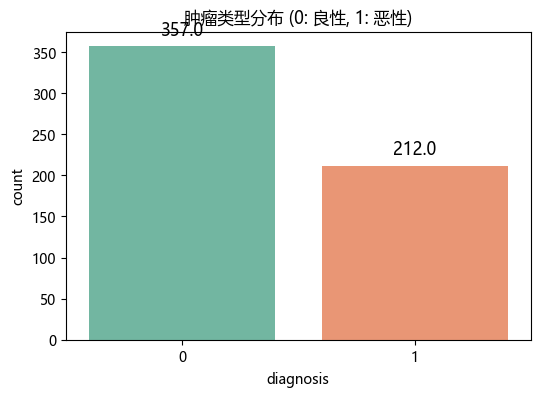

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 可视化类别分布
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='Set2', legend=False)
plt.title('肿瘤类型分布 (0: 良性, 1: 恶性)')

# 在柱状图上添加具体数值
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

可以看到良性与恶性的比例是6：4左右，这说明数据集是可以直接使用的，我们不需要再进行处理。

### 2.1.3 高度相关数据特征查找

在乳腺癌数据集中，许多特征是基于相同的物理属性计算得出的。例如，细胞核的半径、周长和面积在几何学上高度相关。
如果将这些高度相关的特征同时输入给模型，会导致多重共线性问题：模型的权重会变得极不稳定，容易引发过拟合。降低了模型的可解释性。

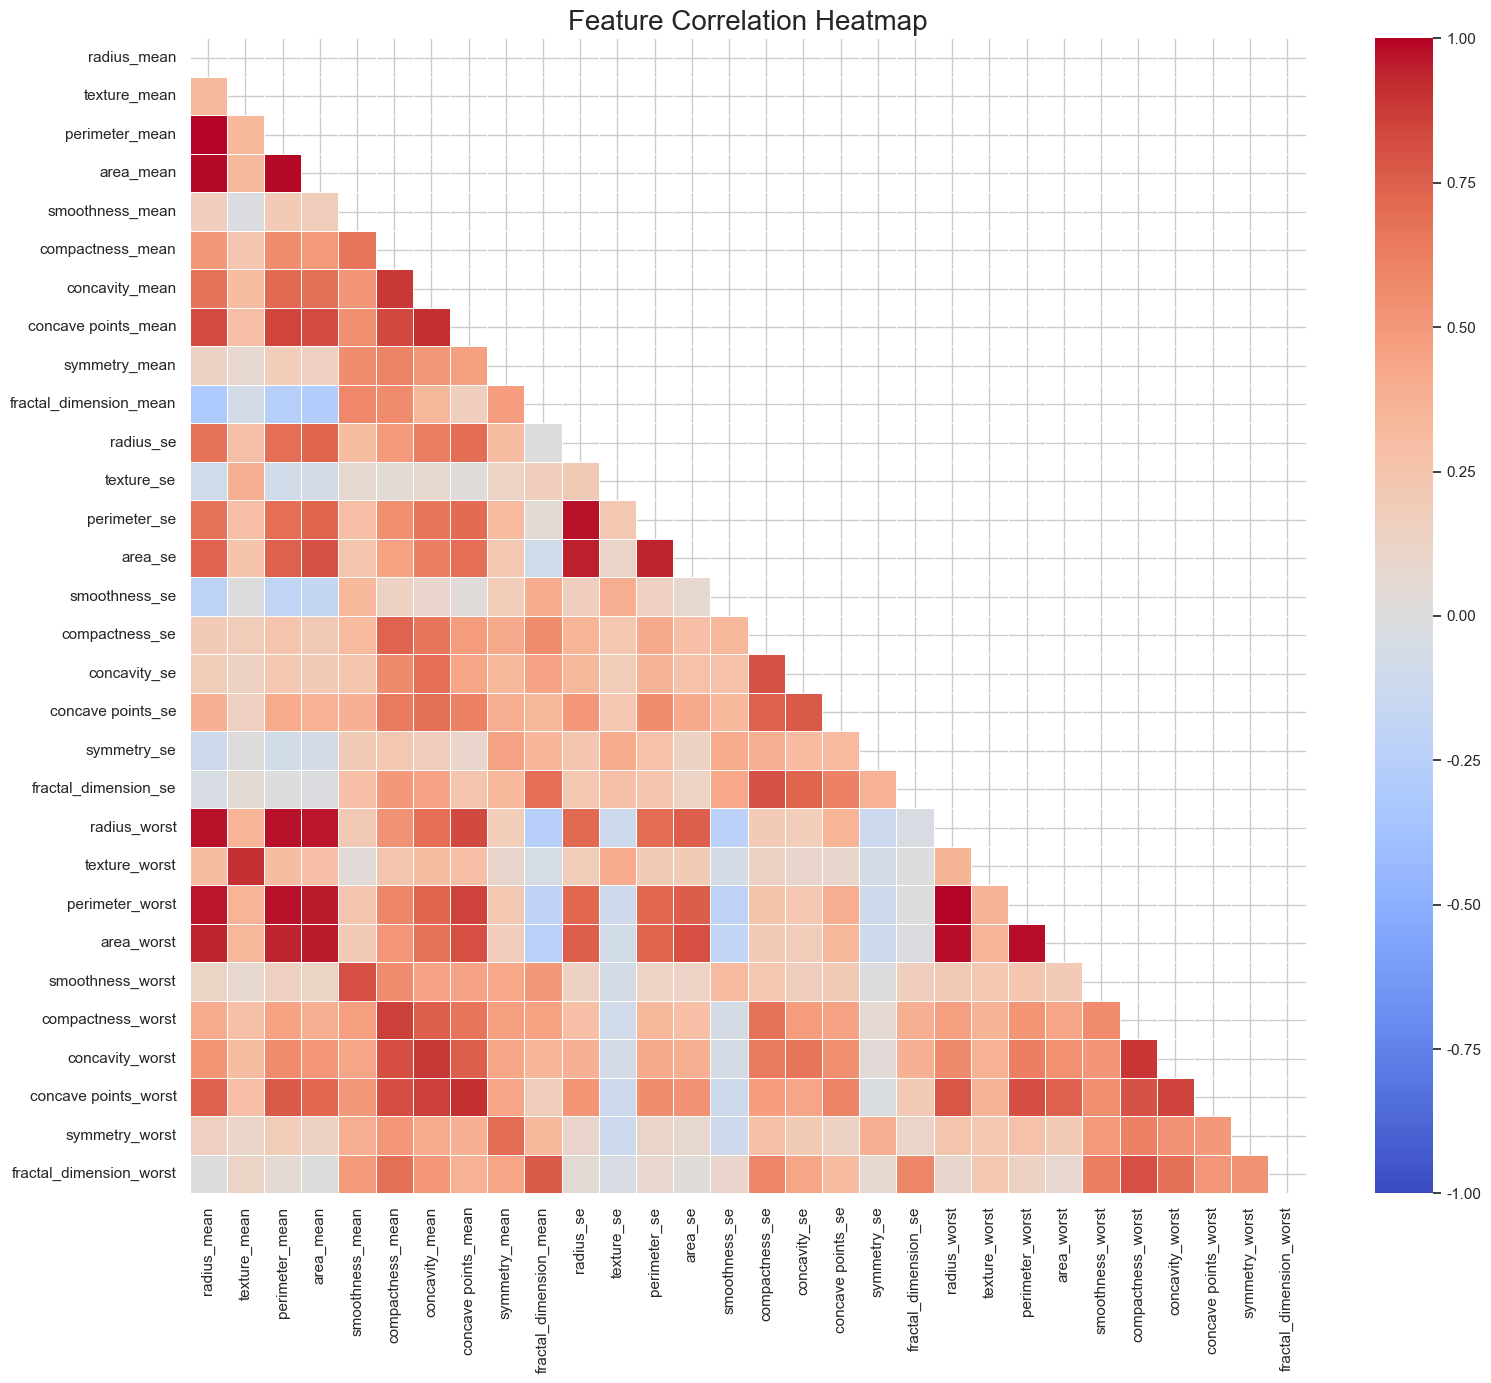

基于相关系数阈值 > 0.9，共发现 10 个需要剔除的冗余特征：
['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']

剔除后，数据集从 31 列精简到了 21 列。


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False 

X_features = df.drop(columns=['diagnosis'])

# 1. 计算相关系数矩阵
corr_matrix = X_features.corr()

# 2. 绘制高阶版热力图
plt.figure(figsize=(18, 15))
# 生成一个与矩阵同大小的布尔矩阵，上三角全为 True
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 绘制热力图
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=20)
plt.show()

# 剔除高共线特征
threshold = 0.90 # 相关系数绝对值大于 0.9

# 寻找上三角矩阵中绝对值大于阈值的元素
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"基于相关系数阈值 > {threshold}，共发现 {len(to_drop)} 个需要剔除的冗余特征：")
print(to_drop)

# 生成降维后的干净数据集
df_reduced = df.drop(columns=to_drop)
print(f"\n剔除后，数据集从 {df.shape[1]} 列精简到了 {df_reduced.shape[1]} 列。")

In [8]:
df_raw = df

### 2.1.4 特征区分度

在前一步中，我们通过相关性分析剔除了高共线性的冗余特征。然而，留下的独立特征在实际的分类任务中贡献度并不相同。
我们将自动计算剩余特征在良性与恶性两组之间的均值差异。
挑选出区分度最强的 2 个特征与最弱的 2 个特征。

挑选出的最强特征: ['radius_mean', 'concavity_mean']
挑选出的最弱特征: ['texture_se', 'symmetry_se']


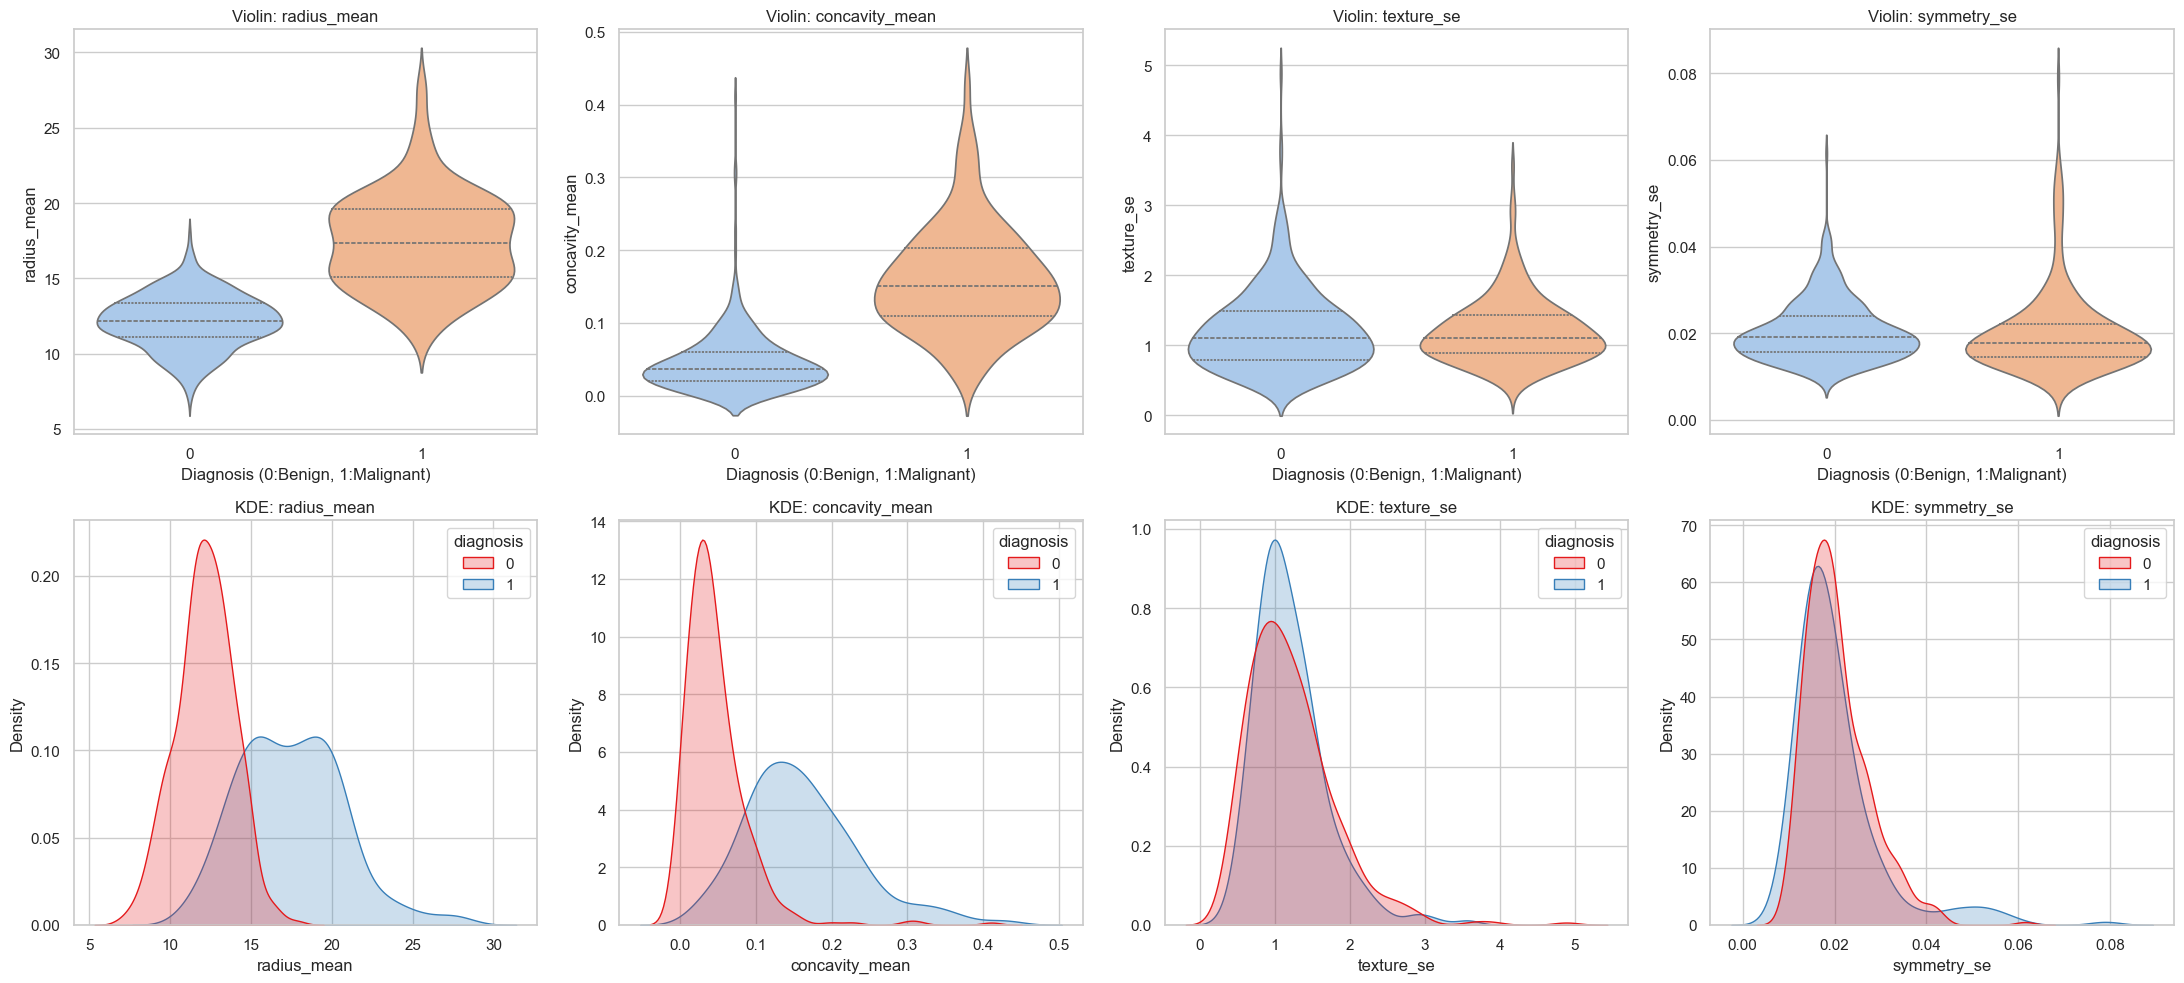

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 计算每个特征的区分度 (使用 T 检验的得分绝对值作为指标)
remaining_features = [col for col in df_reduced.columns if col != 'diagnosis']
scores = {}

for feature in remaining_features:
    benign = df_reduced[df_reduced['diagnosis'] == 0][feature]
    malignant = df_reduced[df_reduced['diagnosis'] == 1][feature]
    t_stat, _ = stats.ttest_ind(benign, malignant, equal_var=False)
    scores[feature] = abs(t_stat)

# 排序并找出最强和最弱的各2个特征
sorted_features = sorted(scores, key=scores.get, reverse=True)
strongest = sorted_features[:2]
weakest = sorted_features[-2:]
features_to_show = strongest + weakest

print(f"挑选出的最强特征: {strongest}")
print(f"挑选出的最弱特征: {weakest}")

# 2. 绘制对比矩阵图 
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10))

# 第一行：小提琴图
for i, feature in enumerate(features_to_show):
    sns.violinplot(x='diagnosis', y=feature, data=df_reduced, ax=axes[0, i], hue='diagnosis', palette='pastel', inner='quartile', legend=False)
    axes[0, i].set_title(f'Violin: {feature}', fontsize=12)
    axes[0, i].set_xlabel('Diagnosis (0:Benign, 1:Malignant)')

# 第二行：KDE密度图
for i, feature in enumerate(features_to_show):
    sns.kdeplot(data=df_reduced, x=feature, hue='diagnosis', fill=True, ax=axes[1, i], palette='Set1', common_norm=False)
    axes[1, i].set_title(f'KDE: {feature}', fontsize=12)
    axes[1, i].set_xlabel(feature)

plt.tight_layout()
plt.show()

从上述小提琴图中可以直观看出，radius_mean 在类别 0 和 1 之间的中位数差异巨大，且分布形态截然不同，说明其区分度高。
而 fractal_dimension_mean 的两类分布高度重合，中位数几乎在同一水平线上，对分类器的贡献预期较低。

### 2.1.5 数据预处理

在我们的数据集中，特征之间的量纲差异巨大。例如，面积特征的数值可达数千，而某些几何特征的数值小于 0.1。如果直接使用未经缩放的数据训练模型，会导致：距离度量失效： 在距离计算中，数值大的特征会完全主导模型，掩盖数值小但区分度高的特征。梯度下降缓慢： 在逻辑回归或支持向量机等模型中，未缩放的数据会导致损失函数的等高线呈狭长形，模型收敛过程伴随剧烈震荡。因此，我们必须应用 StandardScaler 对特征进行标准化处理（$z = \frac{x - \mu}{\sigma}$），将所有特征拉到同一基准线上（均值为 0，标准差为 1）。

此外，我们将数据集按照6：2：2的比例划分了训练集、测试集、验证集。

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def data_process(X,y):
    '''
        6：2：2划分训练测试验证集
    '''
    # 测试集
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # 确保各集合中良性/恶性比例一致
    )

    # 验证集和训练集
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, 
        test_size=0.25, 
        random_state=42, 
        stratify=y_temp
    )
    # 特征缩放 Z-score
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    print(f"数据切分与标准化完成！")
    print(f"--- 训练集 (Train) 占比 60%: {X_train_scaled.shape[0]} 样本")
    print(f"--- 验证集 (Val)   占比 20%: {X_val_scaled.shape[0]} 样本 ")
    print(f"--- 测试集 (Test)  占比 20%: {X_test_scaled.shape[0]} 样本")
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test


In [11]:
X,y = seg_train_label(df)
X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test = data_process(X,y)

数据切分与标准化完成！
--- 训练集 (Train) 占比 60%: 341 样本
--- 验证集 (Val)   占比 20%: 114 样本 
--- 测试集 (Test)  占比 20%: 114 样本


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_model_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

## 3.1 简单逻辑回归模型

作为本项目的第一个分类器，我们选择了机器学习中最经典、最具解释性的算法——**逻辑回归（Logistic Regression）**作为基线模型。所谓基线模型，是指在尝试更复杂的算法之前，先用一个简单模型建立性能参考标准，后续所有模型的结果都将与它对比。

### 核心思想：从线性到概率

逻辑回归的目标是预测某个样本属于某一类别（例如恶性肿瘤）的**概率**，而非直接输出硬性的分类标签。

第一步，对输入特征做线性加权求和：

$$z = w^T x + b$$

其中 $x$ 是 30 维特征向量，$w$ 是每个特征对应的权重，$b$ 是偏置项。这一步在几何上相当于在特征空间中寻找一个能划分两类数据的超平面。

第二步，用 **Sigmoid 函数**将 $z$ 映射到概率值：

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Sigmoid 函数呈 S 型曲线，能将任意实数平滑压缩到 $(0, 1)$ 区间。当 $z$ 很大时输出趋近于 1（高概率恶性），当 $z$ 很小时输出趋近于 0（高概率良性）。实际使用时以 0.5 为默认决策阈值。

### 训练：对数损失 + 梯度下降

训练阶段使用**对数损失函数（交叉熵损失）**衡量预测概率与真实标签的差距：

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

若模型对真实恶性样本给出接近 0 的概率，损失会趋向无穷大，施加极大惩罚。通过梯度下降算法反复迭代，不断调整 $w$，使总损失降到最低。这也正是前面必须对特征进行 Z-score 标准化的原因——量纲不统一会使损失函数等高线呈狭长形，导致梯度下降剧烈震荡、收敛缓慢。

### 逻辑回归的特点

| 优点 | 局限 |
|---|---|
| 模型简单，训练速度快，可解释性强 | 仅能学习线性决策边界，对非线性问题能力有限 |
| 输出概率值，便于设置不同决策阈值 | 需要特征标准化，对量纲敏感 |
| 参数即为各特征的重要性权重 | 特征之间若存在高度共线性，权重会不稳定 |

In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss  

def train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test):
    # 初始化逻辑回归模型
    # warm_start=True 允许我们在调用 fit 时继续上一次的训练，而不是重新开始
    # max_iter=1 表示每次调用 fit 只训练 1 次迭代
    model = LogisticRegression(random_state=42, max_iter=1, warm_start=True)
    
    total_epochs = 100  # 设定总的训练轮数
    loss_history = []   # 用于记录损失值
    
    # 逐步训练并记录损失
    for epoch in range(total_epochs):
        model.fit(X_train_scaled, y_train)
        
        # 使用 predict_proba 获取概率矩阵，然后使用 log_loss 计算交叉熵损失
        y_train_proba = model.predict_proba(X_train_scaled)
        loss = log_loss(y_train, y_train_proba)
        
        loss_history.append(loss)
        
        # 每10轮打印一次进度
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{total_epochs}, Loss: {loss:.4f}")
    
    # 预测
    y_pred = model.predict(X_test_scaled)

    # 评估模型表现
    results = get_model_metrics(y_test, y_pred)
    
    print(f"Accuracy: {results['Accuracy']:.4f} ")
    print(f"Precision: {results['Precision']:.4f} ")
    print(f"Recall: {results['Recall']:.4f} ")
    print(f"F1-Score: {results['F1-Score']:.4f} ")
    
    # 绘制损失曲线
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, label='Training Loss', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Logistic Regression Training Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return model, y_pred

Epoch 10/100, Loss: 0.0625
Epoch 20/100, Loss: 0.0523
Epoch 30/100, Loss: 0.0530
Epoch 40/100, Loss: 0.0531
Epoch 50/100, Loss: 0.0532
Epoch 60/100, Loss: 0.0532
Epoch 70/100, Loss: 0.0532
Epoch 80/100, Loss: 0.0532
Epoch 90/100, Loss: 0.0532
Epoch 100/100, Loss: 0.0532
Accuracy: 0.9737 
Precision: 0.9756 
Recall: 0.9524 
F1-Score: 0.9639 


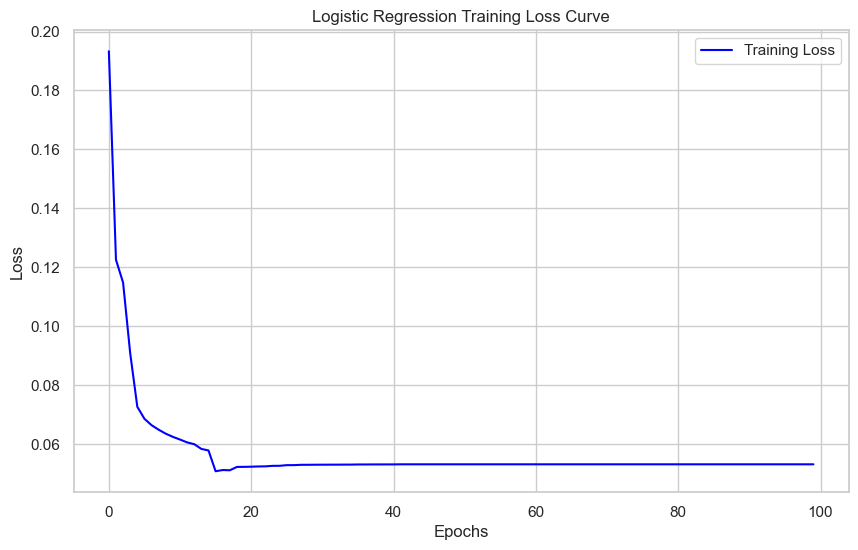

(LogisticRegression(max_iter=1, random_state=42, warm_start=True),
 array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
        1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 1], dtype=int64))

In [14]:
train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test)

## 3.2 支持向量机 SVM 
支持向量机（Support Vector Machine, SVM）是一种基于统计学习理论的监督学习算法，其核心思想是在特征空间中寻找一个**最优超平面（Optimal Hyperplane）**，使得两类样本之间的**分类间隔（Margin）最大化**。

---

#### 基本原理：最大间隔分类器

对于一个线性可分的二分类问题，可以画出无数条能将两类数据分开的直线（或超平面）。SVM 的独特之处在于，它不是随意找一条分界线，而是寻找那条**距离两侧最近样本点最远**的分界线。

这些距离分界线最近的样本点，被称为**支持向量（Support Vectors）**——SVM 名字的由来正是如此。只有支持向量决定了最终的超平面位置，其他远离边界的样本点对模型没有任何影响。这一性质让 SVM 在高维小样本场景下表现出色，对噪声也相对鲁棒。

数学上，SVM 的优化目标是：

$$\min_{w,b} \frac{1}{2} \|w\|^2 \quad \text{s.t.} \quad y_i(w^T x_i + b) \geq 1, \forall i$$

最大化间隔等价于最小化 $\|w\|^2$，这是一个凸二次规划问题，有唯一全局最优解。

---

#### 核心技术：核函数（Kernel Trick）

现实数据往往并非线性可分——两类肿瘤的特征在原始 30 维空间中可能存在复杂的非线性边界。SVM 通过**核函数（Kernel Function）**巧妙地解决了这一问题。

核函数的本质是：将原始特征空间隐式地映射到一个**更高维甚至无穷维的空间**，使得在低维线性不可分的数据，在高维空间中变得线性可分，然后在高维空间中寻找最优超平面。

核技巧最精妙之处在于：我们**不需要显式地计算高维坐标**，只需要计算两个样本在高维空间中的内积，而这可以通过核函数直接在低维完成，计算开销极小。

本项目使用 **RBF 核（径向基函数核，Radial Basis Function）**：

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

RBF 核的直觉理解是：两个样本距离越近，核函数值越大（越相似）；距离越远，核函数值趋近于 0。它能够建模出无限复杂的决策边界，是处理非线性分类问题时最常用的核函数之一。

---

#### SVM 的特点

| 优点 | 局限 |
|---|---|
| 在高维特征空间中仍然有效，适合特征数多于样本数的场景 | 对大规模数据集训练速度较慢（训练复杂度约为 $O(n^2)$ 到 $O(n^3)$）|
| 仅由支持向量决定模型，对噪声鲁棒性好 | 对特征缩放敏感，必须先进行标准化 |
| 核函数使其具备强大的非线性建模能力 | 超参数 C（惩罚系数）和 γ（RBF 核宽度）调优较麻烦 |
| 凸优化问题，有唯一最优解，不存在局部最优陷阱 | 输出的是决策值，概率校准需要额外计算（Platt Scaling）|

在本项目中，由于已经对数据进行了 Z-score 标准化，SVM 可以充分发挥其在中等规模、高维结构化数据上的优势。

### 3.2.1环境配置

In [15]:
# 导入SVM模型所需库
from sklearn.svm import SVC

### 3.2.2模型构建与训练

In [16]:
def build_svm_model(random_state=42):
    """
    构建并返回支持向量机模型
    :return: 初始化好的SVM模型
    """
    model = SVC(
        kernel='rbf',        # 核函数：非线性分类能力更强
        probability=True,    # 输出概率，方便后续评估
        random_state=random_state #随机数种子保证结果可复现
    )
    return model
#初始化模型
svm_model = build_svm_model()
# 训练模型
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

### 3.2.3模型预测

In [17]:
def predict_model(model, X_test):
    return model.predict(X_test)

# 开始预测
y_pred_svm = predict_model(svm_model, X_test_scaled)

### 3.2.4 模型评估

In [18]:
def evaluate_model(y_true, y_pred, model_name="SVM"):
  
    metrics = get_model_metrics(y_true, y_pred)
    print(f"{model_name} 模型评估结果")
    print(f"准确率  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"精确率  Precision: {metrics['Precision']:.4f}")
    print(f"召回率  Recall: {metrics['Recall']:.4f}")
    print(f"F1分数  F1-Score: {metrics['F1-Score']:.4f}")
    
    return metrics

# 评估SVM模型
svm_metrics = evaluate_model(y_test, y_pred_svm, model_name="支持向量机 SVM")

支持向量机 SVM 模型评估结果
准确率  Accuracy: 0.9737
精确率  Precision: 0.9756
召回率  Recall: 0.9524
F1分数  F1-Score: 0.9639


## 3.3 随机森林
随机森林（Random Forest）是一种基于**集成学习（Ensemble Learning）**思想的算法，其核心策略是"三个臭皮匠顶一个诸葛亮"——通过构建大量相互独立的弱分类器（决策树），再将它们的预测结果通过投票（分类）或平均（回归）的方式汇总，从而得到比任何单一模型都更准确、更稳定的预测结果。

---

#### 基础组件：决策树

理解随机森林，首先要理解它的基础组件——**决策树（Decision Tree）**。决策树是一种树状结构的分类器，它通过一系列"如果…那么…"的判断规则将数据逐步分类。

例如，对于乳腺癌分类，一棵简单的决策树可能会问：
- "radius_mean > 15？"→ 是 → "concave_points_mean > 0.05？" → 是 → 预测为恶性
- "radius_mean > 15？"→ 否 → 预测为良性

决策树在每个节点选择分裂特征的依据是**信息增益（Information Gain）**或**基尼不纯度（Gini Impurity）**——选择使分裂后子节点类别最"纯"的特征。

单棵决策树的问题在于**方差高（High Variance）**：对训练数据的微小变化非常敏感，容易过拟合。

---

#### 核心机制：Bagging + 特征随机采样

随机森林通过两层随机性克服决策树的过拟合问题：

**第一层：Bootstrap 自助采样（Bagging）**

对于包含 $n$ 个样本的训练集，每棵决策树都从中**有放回地随机抽取** $n$ 个样本（约 63.2% 的样本会被选中，剩余约 36.8% 作为袋外数据 OOB 可用于内部验证）。由于每棵树看到的训练集略有不同，它们会学到数据的不同局部特征，彼此之间具有**差异性（Diversity）**。

**第二层：特征随机子空间**

在每个决策节点进行特征选择时，随机森林不会考虑所有特征，而是**随机抽取 $\sqrt{p}$（分类任务）个特征**作为候选（$p$ 为总特征数）。这进一步降低了各棵树之间的相关性，使集成效果更好。

**汇总：多数投票**

最终预测时，让所有决策树各自独立作出预测，采用**多数投票**决定最终类别。对于我们的乳腺癌二分类任务，若 100 棵树中有 70 棵预测为恶性，则最终判定为恶性。

---

#### 随机森林的特点

| 优点 | 局限 |
|---|---|
| 集成大量决策树，泛化能力强，不易过拟合 | 模型由数百棵树组成，可解释性远不如单棵决策树 |
| 对特征缩放不敏感（决策树基于排序，非距离） | 对极度不平衡的数据集需要调整类别权重 |
| 可计算特征重要性，具备一定可解释性 | 模型体积大，预测速度比单个模型慢 |
| 内置 OOB 误差估计，无需额外验证集也能评估性能 | 超参数（树的数量、最大深度等）需要调整 |
| 对缺失值和离群值有较好的鲁棒性 | 在某些线性可分的简单问题上可能不如逻辑回归高效 |

在本项目中，由于特征数量（30个）适中，随机森林的特征随机采样机制能够有效发挥作用，同时其特征重要性输出也为理解哪些细胞核指标最具诊断价值提供了重要参考。

In [19]:
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

### 3.3.1环境配置和建立随机森林模型

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

### 3.3.2 训练随机森林模型

In [21]:
print("正在训练随机森林模型...")
# 使用标准化后的数据进行训练
rf_model.fit(X_train_scaled, y_train)
print("模型训练完成！")

正在训练随机森林模型...
模型训练完成！


### 3.3.3 模型预测与评估

In [22]:
# 在训练集上预测
y_train_pred = rf_model.predict(X_train_scaled)
# 在验证集上预测
y_val_pred = rf_model.predict(X_val_scaled)
# 在测试集上预测
y_test_pred = rf_model.predict(X_test_scaled)

In [23]:
# 调用 get_model_metrics 函数评估
train_metrics = get_model_metrics(y_train, y_train_pred)
# 验证集用于看是否过拟合
val_metrics = get_model_metrics(y_val, y_val_pred)
test_metrics = get_model_metrics(y_test, y_test_pred)

print("\n===== 训练集 (train Set) 表现 =====")
for k, v in train_metrics.items():
    print(f"{k}: {v:.4f}")
    
print("\n===== 验证集 (Validation Set) 表现 =====")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n===== 测试集 (Test Set) 表现 =====")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

# 打印详细分类报告
print("\n--- 测试集详细分类报告 ---")
print(classification_report(y_test, y_test_pred, target_names=['良性(B)', '恶性(M)']))


===== 训练集 (train Set) 表现 =====
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

===== 验证集 (Validation Set) 表现 =====
Accuracy: 0.9737
Precision: 0.9762
Recall: 0.9535
F1-Score: 0.9647

===== 测试集 (Test Set) 表现 =====
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1-Score: 0.9383

--- 测试集详细分类报告 ---
              precision    recall  f1-score   support

       良性(B)       0.95      0.99      0.97        72
       恶性(M)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 3.4 全连接神经网络（FCNN）

本节基于 Kaggle 乳腺癌数据集，使用 **全连接神经网络（Fully Connected Neural Network, FCNN）** 完成二分类任务：判断肿瘤为恶性（Malignant, 1）或良性（Benign, 0）。

---

### FCNN 原理简介

全连接神经网络（FCNN），也称为**多层感知机（Multi-Layer Perceptron, MLP）**，是深度学习领域中历史最悠久、结构最基础的神经网络架构。理解 FCNN 是进入深度学习领域的第一步，下文将从生物启发出发，系统介绍其核心原理。

#### 生物神经元与人工神经元

FCNN 的设计灵感来源于人类大脑的神经系统。人脑中约有 860 亿个神经元，每个神经元通过树突（dendrites）接收来自其他神经元的信号，在细胞体（soma）中对信号进行整合，当累积信号超过某个激活阈值时，通过轴突（axon）向下一个神经元发放电信号。

人工神经元对这一过程进行了数学抽象：
- **输入（Input）**：接收来自上一层神经元的数值信号 $x_1, x_2, \ldots, x_n$
- **权重（Weight）**：每个输入连接都有一个对应的权重 $w_i$，代表该信号的重要程度
- **偏置（Bias）**：一个可学习的常数 $b$，控制神经元的激活阈值
- **线性组合**：计算加权求和 $z = \sum_{i=1}^n w_i x_i + b$
- **激活函数（Activation Function）**：将 $z$ 通过非线性函数 $f(z)$ 映射为输出，引入非线性能力

#### 为什么需要激活函数（非线性）？

如果没有激活函数，无论叠加多少层线性变换，整个网络等价于一个单一的线性变换，无法拟合复杂的非线性数据边界。激活函数的引入让网络具备了逼近任意复杂函数的能力（万能近似定理）。

常见的激活函数包括：

- **Sigmoid**：$\sigma(z) = \frac{1}{1+e^{-z}}$，输出范围 $(0,1)$，适合输出层表示概率，但在深层网络中容易出现**梯度消失**问题
- **ReLU（线性整流单元）**：$f(z) = \max(0, z)$，计算简单，在大多数隐藏层中是当前最流行的选择，能有效缓解梯度消失
- **Tanh**：输出范围 $(-1,1)$，比 Sigmoid 对称，但同样有梯度消失问题

本项目在隐藏层使用 **ReLU**，在输出层使用 **Sigmoid**（因为输出需要表示"恶性概率"，值域应在 $[0,1]$）。

#### 网络架构：层与层之间的全连接

FCNN 的核心特征是"全连接"——每一层的**每个神经元**都与下一层的**所有神经元**相连。这种结构能够捕获任意特征之间的交互关系，但也导致参数数量较多。

本项目的网络架构如下：

```
输入层 (30维) → 隐藏层1 (64神经元) → 隐藏层2 (32神经元) → 隐藏层3 (16神经元) → 输出层 (1神经元)
```

每个隐藏层中还加入了两项重要的正则化技术：
- **批归一化（Batch Normalization, BN）**：对每个批次的输入进行归一化，使每层的输入分布保持稳定，大幅加速训练收敛，降低对学习率选择的敏感性
- **Dropout**：在训练时以一定概率随机将部分神经元的输出置为零，迫使网络不依赖于某些特定神经元，是一种非常有效的防止过拟合的手段。由于本数据集训练样本仅约 340 个，过拟合风险较高，Dropout 在此尤为重要

#### 前向传播（Forward Propagation）

网络接收输入数据后，信号从输入层出发，逐层向前传递，经过每一层的线性变换和非线性激活，最终在输出层产生预测结果的过程，称为**前向传播**。对于二分类任务，输出层的 Sigmoid 函数将最终的线性得分映射为一个概率值 $\hat{p} \in (0,1)$，若 $\hat{p} \geq 0.5$ 则预测为恶性，否则预测为良性。

#### 损失函数与反向传播（Backpropagation）

**二元交叉熵损失（Binary Cross-Entropy Loss, BCELoss）** 是二分类任务中最常用的损失函数：

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

该损失函数的直觉理解是：当模型对一个真实为恶性（$y=1$）的样本给出接近 0 的预测概率时，$\log(\hat{p})$ 趋向负无穷，损失极大；当预测概率接近 1 时，损失趋向 0。

**反向传播**是训练神经网络的核心算法。它利用微积分中的**链式法则（Chain Rule）**，从输出层的损失值出发，逐层向后计算每个参数对损失的偏导数（梯度），然后利用这些梯度通过**优化器**更新参数，使损失逐步降低。

本项目使用 **Adam 优化器**（Adaptive Moment Estimation），它在梯度下降的基础上引入了动量（momentum）和自适应学习率机制，相比普通的随机梯度下降（SGD）收敛更快、对学习率的初始设置也更加鲁棒。

### FCNN 的特点总结

| 优点 | 局限 |
|---|---|
| 可以自动学习特征间的高阶非线性交互关系 | 参数量较多，小数据集上容易过拟合（需 Dropout/BN 缓解） |
| 通过多层结构提取更抽象的特征表示 | 模型可解释性较弱，不如逻辑回归直观 |
| 灵活性高，可通过调整层数、神经元数、激活函数等适应不同任务 | 超参数（学习率、层数、Dropout率等）调优需要经验 |
| 配合 Early Stopping 可有效控制过拟合 | 训练时间比传统机器学习方法更长 |

---

### 3.4.1 环境配置

本节导入神经网络所需的额外库。模型框架选用 **PyTorch**，原因在于其动态计算图便于调试，API 轻量灵活，且与 scikit-learn 的预处理流程（numpy 数组）直接兼容，非常适合处理本项目这类结构化表格数据。

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib
matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

SEED_FCNN = 42
torch.manual_seed(SEED_FCNN)
np.random.seed(SEED_FCNN)

print(f"PyTorch 版本: {torch.__version__}")
device_fcnn = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前计算设备: {device_fcnn}")

PyTorch 版本: 2.2.2+cpu
当前计算设备: cpu


### 3.4.2 构建数据加载器

PyTorch 推荐用 `DataLoader` 管理批次化训练，将 numpy 数组封装为可迭代的 mini-batch。这里直接复用前面已经处理好的 `X_train_scaled`、`X_val_scaled`、`X_test_scaled` 等数组，无需重复数据清洗。

In [25]:
def build_dataloader_fcnn(X, y, batch_size=32, shuffle=True):
    """
    将 numpy 特征矩阵和标签封装为 PyTorch DataLoader。
    shuffle=True 用于训练集，验证/测试集设为 False。
    """
    X_tensor = torch.FloatTensor(X).to(device_fcnn)
    y_tensor = torch.FloatTensor(np.array(y)).unsqueeze(1).to(device_fcnn)
    dataset  = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE_FCNN = 32
train_loader_fcnn = build_dataloader_fcnn(X_train_scaled, y_train, batch_size=BATCH_SIZE_FCNN, shuffle=True)
val_loader_fcnn   = build_dataloader_fcnn(X_val_scaled,   y_val,   batch_size=BATCH_SIZE_FCNN, shuffle=False)
test_loader_fcnn  = build_dataloader_fcnn(X_test_scaled,  y_test,  batch_size=BATCH_SIZE_FCNN, shuffle=False)

print(f"每个 epoch 共 {len(train_loader_fcnn)} 个 batch（batch_size={BATCH_SIZE_FCNN}）")

每个 epoch 共 11 个 batch（batch_size=32）


### 3.4.3 定义网络结构

按照前文介绍的架构（30→64→32→16→1）构建网络，隐藏层使用 ReLU 激活、BatchNorm 和 Dropout，输出层使用 Sigmoid 输出恶性概率。

In [26]:
class BreastCancerFCNN(nn.Module):
    """
    用于乳腺癌二分类的全连接神经网络。
    结构：30 -> 64 -> 32 -> 16 -> 1
    隐藏层后接 BatchNorm 和 Dropout，输出层使用 Sigmoid。
    """

    def __init__(self, input_dim=30, dropout_rate=0.3):
        super(BreastCancerFCNN, self).__init__()
        self.network = nn.Sequential(
            # 第一隐藏层
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # 第二隐藏层
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # 第三隐藏层
            nn.Linear(32, 16),
            nn.ReLU(),
            # 输出层：Sigmoid 将结果压缩到 [0,1]，表示恶性概率
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        """前向传播：输入特征张量，输出恶性概率。"""
        return self.network(x)

fcnn_model = BreastCancerFCNN(input_dim=X_train_scaled.shape[1]).to(device_fcnn)
print(fcnn_model)
print(f"\n模型总参数量: {sum(p.numel() for p in fcnn_model.parameters())}")

BreastCancerFCNN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

模型总参数量: 4801


### 3.4.4 损失函数与优化器

选用 **BCELoss** 与 Sigmoid 搭配；优化器用 **Adam**（自适应学习率，收敛快）；加 **L2 正则化**（`weight_decay`）防过拟合；用 **ReduceLROnPlateau** 调度器在验证损失停滞时自动减半学习率。

In [27]:
criterion_fcnn = nn.BCELoss()

optimizer_fcnn = optim.Adam(
    fcnn_model.parameters(),
    lr=1e-3,          # 初始学习率
    weight_decay=1e-4 # L2 正则化系数
)

scheduler_fcnn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fcnn, mode='min', factor=0.5, patience=10
)

print("损失函数: BCELoss")
print("优化器:   Adam (lr=1e-3, weight_decay=1e-4)")
print("调度器:   ReduceLROnPlateau (patience=10, factor=0.5)")

损失函数: BCELoss
优化器:   Adam (lr=1e-3, weight_decay=1e-4)
调度器:   ReduceLROnPlateau (patience=10, factor=0.5)


### 3.4.5 训练流程

每个 epoch 分两阶段：训练（开启 Dropout/BN 随机性）和验证（关闭随机性，`torch.no_grad()`）。加入 **Early Stopping**：验证损失连续 20 epoch 无改善则提前终止，并自动还原至最佳权重，防止模型在训练后期对训练集过拟合。

In [28]:
def train_model_fcnn(model, train_loader, val_loader, criterion, optimizer,
                scheduler, epochs=200, patience=20):
    """
    训练与验证主循环，内置 Early Stopping。
    返回各 epoch 的训练损失和验证损失列表（用于绘图）。
    """
    train_losses_fcnn, val_losses_fcnn = [], []
    best_val_loss    = float('inf')
    best_weights     = None
    no_improve_count = 0

    for epoch in range(1, epochs + 1):
        # ── 训练阶段 ──
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ── 验证阶段 ──
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_running_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        train_losses_fcnn.append(train_loss)
        val_losses_fcnn.append(val_loss)
        scheduler.step(val_loss)

        # ── Early Stopping 判断 ──
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"\n[Early Stopping] 第 {epoch} epoch 触发，已还原最佳权重。")
                model.load_state_dict(best_weights)
                break

        if epoch % 20 == 0:
            print(f"Epoch [{epoch:>3}/{epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    if best_weights:
        model.load_state_dict(best_weights)

    return train_losses_fcnn, val_losses_fcnn

train_losses_fcnn, val_losses_fcnn = train_model_fcnn(
    fcnn_model, train_loader_fcnn, val_loader_fcnn,
    criterion_fcnn, optimizer_fcnn, scheduler_fcnn,
    epochs=200, patience=20
)

Epoch [ 20/200]  Train Loss: 0.0964  Val Loss: 0.0763
Epoch [ 40/200]  Train Loss: 0.0530  Val Loss: 0.0633
Epoch [ 60/200]  Train Loss: 0.0893  Val Loss: 0.0663

[Early Stopping] 第 67 epoch 触发，已还原最佳权重。


### 3.4.6 训练过程可视化

绘制训练集与验证集的损失曲线，观察模型的收敛情况。若两条曲线均持续下降并趋于稳定，说明训练正常；若验证集损失在某处开始上升而训练集损失仍在下降，则表明出现了过拟合。

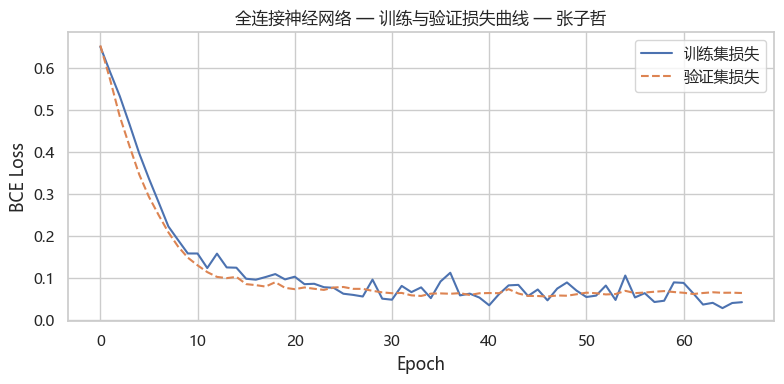

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_fcnn, label='训练集损失', linewidth=1.5)
plt.plot(val_losses_fcnn,   label='验证集损失', linewidth=1.5, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('全连接神经网络 — 训练与验证损失曲线 — 张子哲')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4.7 模型评估

在测试集和验证集上分别评估模型，计算 Accuracy、Precision、Recall、F1 Score 和 AUC-ROC 五项指标。

In [30]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

def evaluate_model_fcnn(model, data_loader, threshold=0.5):
    """
    在给定 DataLoader 上评估模型，返回预测标签、预测概率和真实标签。
    threshold：概率阈值，高于此值判定为恶性（1）。
    """
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            all_probs.extend(model(X_batch).cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int)
    return all_preds, all_probs, all_labels


def print_metrics_fcnn(y_true, y_pred, y_prob, dataset_name='测试集'):
    """打印 Accuracy / Precision / Recall / F1 / AUC-ROC 五项指标。"""
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1 Score' : f1_score(y_true, y_pred),
        'AUC-ROC'  : roc_auc_score(y_true, y_prob),
    }
    print(f"\n{'='*40}")
    print(f"  {dataset_name} 评估结果")
    print(f"{'='*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"{'='*40}")
    return metrics

# ── 测试集最终评估 ──
y_pred_test_fcnn, y_prob_test_fcnn, y_true_test_fcnn = evaluate_model_fcnn(fcnn_model, test_loader_fcnn)
test_metrics_fcnn = print_metrics_fcnn(y_true_test_fcnn, y_pred_test_fcnn, y_prob_test_fcnn, '测试集')

# ── 验证集（与测试集对比，确认无严重过拟合）──
y_pred_val_fcnn, y_prob_val_fcnn, y_true_val_fcnn = evaluate_model_fcnn(fcnn_model, val_loader_fcnn)
val_metrics_fcnn = print_metrics_fcnn(y_true_val_fcnn, y_pred_val_fcnn, y_prob_val_fcnn, '验证集')


  测试集 评估结果
  Accuracy    : 0.9825
  Precision   : 1.0000
  Recall      : 0.9524
  F1 Score    : 0.9756
  AUC-ROC     : 0.9954

  验证集 评估结果
  Accuracy    : 0.9912
  Precision   : 1.0000
  Recall      : 0.9767
  F1 Score    : 0.9882
  AUC-ROC     : 0.9967


### 3.4.8 指标汇总

将验证集与测试集的五项指标整合为对比表，方便与其他算法横向比较。

In [31]:
import pandas as pd
summary_fcnn = pd.DataFrame({'验证集': val_metrics_fcnn, '测试集': test_metrics_fcnn}).T
summary_fcnn = summary_fcnn[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']]
print("\n全连接神经网络 指标汇总：")
print(summary_fcnn.to_string(float_format='{:.4f}'.format))


全连接神经网络 指标汇总：
     Accuracy  Precision  Recall  F1 Score  AUC-ROC
验证集    0.9912     1.0000  0.9767    0.9882   0.9967
测试集    0.9825     1.0000  0.9524    0.9756   0.9954


## 3.5 XGBoost
XGBoost（eXtreme Gradient Boosting）是由陈天奇于 2016 年提出的梯度提升算法的高效工程实现，曾在数百场 Kaggle 结构化数据竞赛中摘得桂冠，被誉为"竞赛神器"。与随机森林的并行独立建树不同，XGBoost 属于**提升（Boosting）**方法，采用**串行迭代、逐步纠错**的策略。

---

#### 核心思想：梯度提升（Gradient Boosting）

Boosting 的哲学是：与其一次性建一个强模型，不如让许多弱模型**前赴后继、互相补充**。

具体过程如下：

1. **第 1 轮**：用一棵浅层决策树（弱学习器）拟合原始数据，得到预测值 $\hat{y}^{(1)}$，计算残差（预测值与真实值的差距）
2. **第 2 轮**：用第二棵决策树去**拟合第 1 轮的残差**（专门纠正第 1 棵树犯的错误），得到修正量
3. **第 $t$ 轮**：新加入的树专注于拟合前 $t-1$ 棵树**还没学好的部分**（残差）
4. **最终预测**：将所有树的预测结果加权求和

$$\hat{y}^{(T)} = \sum_{t=1}^T \eta \cdot f_t(x)$$

其中 $\eta$ 为学习率（缩减系数），防止单棵树的影响过大，提升泛化能力。

**"梯度"提升**的含义是：XGBoost 将残差的拟合过程统一为对损失函数的**负梯度下降**，使得该框架可以适配任意可微的损失函数（二分类用对数损失，回归用均方误差等），具有极强的通用性。

---

#### XGBoost 相比原版 GBDT 的改进

XGBoost 之所以"eXtreme"，在于它在原版梯度提升决策树（GBDT）的基础上引入了大量工程与算法层面的优化：

| 改进点 | 说明 |
|---|---|
| **二阶泰勒展开** | 同时利用损失函数的一阶梯度（方向）和二阶梯度（曲率），使树的分裂决策更精准 |
| **正则化项** | 在目标函数中显式加入叶子节点数量和叶子权重的 L1/L2 惩罚，天然防止过拟合 |
| **列采样（Column Subsampling）** | 类似随机森林，每棵树只用部分特征，增加多样性 |
| **行采样（Row Subsampling）** | 每棵树只用部分样本，进一步降低过拟合 |
| **稀疏感知算法** | 高效处理缺失值，无需手动填充 |
| **并行化** | 特征排序并行计算，训练速度极快 |
| **Early Stopping** | 当验证集指标不再提升时自动停止，避免过拟合和无效迭代 |

---

#### XGBoost 的特点

| 优点 | 局限 |
|---|---|
| 在结构化/表格数据上综合性能极强，是业界标杆 | 超参数众多（学习率、树深度、采样率等），调优复杂 |
| 内置正则化，过拟合风险低 | 相比随机森林，串行建树导致难以完全并行，超大数据集下速度不占优 |
| 支持自定义损失函数，灵活性高 | 可解释性较弱（黑盒模型） |
| Early Stopping 机制有效控制模型复杂度 | 对内存消耗较大 |
| 特征重要性输出，具备一定可解释性 | 对类别不平衡数据需要手动调整 `scale_pos_weight` 参数 |

在本项目中，XGBoost 作为最后一个对比模型登场，其强大的集成能力和内置正则化机制预计能在准确率和召回率上取得不错的综合表现。

###  3.5.1 环境配置

In [32]:
import xgboost as xgb

### 3.5.2数据格式构建

In [33]:
df = data_clean()
#提取特征名称列表
feature_names = df.drop('diagnosis', axis=1).columns.tolist()
#在构建 DMatrix 时传入特征名
dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=feature_names)
dval   = xgb.DMatrix(X_val_scaled,   label=y_val,   feature_names=feature_names)
dtest  = xgb.DMatrix(X_test_scaled,  label=y_test,  feature_names=feature_names)

### 3.5.3 参数配置

In [34]:
params = {
    'objective': 'binary:logistic', # 二分类任务
    'eval_metric': 'auc',           # 评估指标：AUC
    'max_depth': 4,                 # 树的最大深度，控制模型复杂度
    'learning_rate': 0.1,           # 学习率
    'subsample': 0.8,               # 随机采样训练样本比例
    'colsample_bytree': 0.8,        # 随机采样特征比例
    'gamma': 0.1,                   # 节点分裂所需的最小损失下降值
    'min_child_weight': 3,          # 叶子节点最小样本权重和
    'random_state': 42,
    'verbosity': 0                  # 静默模式
}

### 3.5.4模型训练

In [35]:
modelxg = xgb.train(
    params, 
    dtrain,
    num_boost_round=1000,               # 最大迭代次数
    evals=[(dtrain, 'Train'), (dval, 'Val')], # 监控训练集和验证集
    early_stopping_rounds=50,           # 若50轮内指标不提升则停止
    verbose_eval=100                    # 每100轮输出一次日志
)

[0]	Train-auc:0.97226	Val-auc:0.96184
[100]	Train-auc:0.99897	Val-auc:0.99181
[162]	Train-auc:0.99919	Val-auc:0.99279


### 3.5.5模型评估

In [36]:
# --- 5. 结果输出 ---
print(f"\n最佳迭代轮数: {modelxg.best_iteration}")
print(f"验证集最佳 AUC: {modelxg.best_score:.4f}")

# --- 6. 测试集评估 ---
# 预测概率 -> 转为 0/1 标签 (阈值 0.5)
y_pred = (modelxg.predict(dtest) >= 0.5).astype(int)

# 调用自定义函数计算指标
metrics = get_model_metrics(y_test, y_pred)

print("\n===== 测试集性能指标 =====")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


最佳迭代轮数: 112
验证集最佳 AUC: 0.9928

===== 测试集性能指标 =====
Accuracy: 0.9737
Precision: 1.0000
Recall: 0.9286
F1-Score: 0.9630


## 4.1 评估指标对比
5个模型的4个指标（共20）列表对比

In [37]:
import pandas as pd

data = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'FCNN', 'XGBoost'],
    'Accuracy': [0.9737, 0.9737, 0.9561, 0.9912, 0.9737],
    'Precision': [0.9756, 0.9756, 0.9744, 1.0000, 1.0000],
    'Recall': [0.9524, 0.9524, 0.9048, 0.9767, 0.9286],
    'F1-Score': [0.9639, 0.9639, 0.9383, 0.9882, 0.9630]
}

# 创建 DataFrame
df = pd.DataFrame(data)

# 设置索引为模型名称（可选，让表格更紧凑）
df.set_index('Model', inplace=True)

# 定义一个函数来高亮最大值
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold; color: red' if v else '' for v in is_max]

# 绘制表格
# caption: 添加表头
# table_styles: 添加边框和悬停效果
# format: 保留4位小数
# apply: 应用高亮函数
styled_table = (df.style
                .set_caption("五种模型性能对比——戴婧婕")
                .set_table_styles([
                    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center')]},
                    {'selector': 'th', 'props': [('font-size', '14px'), ('text-align', 'center'), ('background-color', '#f0f0f0')]},
                    {'selector': 'td', 'props': [('font-size', '13px'), ('text-align', 'center')]},
                    {'selector': 'tr:hover', 'props': [('background-color', '#ffffcc')]}
                ])
                .format(precision=4)
                .apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
                .set_properties(**{'border': '1px solid black', 'padding': '8px'})
               )

# 显示表格
styled_table

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9737,0.9756,0.9524,0.9639
SVM,0.9737,0.9756,0.9524,0.9639
Random Forest,0.9561,0.9744,0.9048,0.9383
FCNN,0.9912,1.0000,0.9767,0.9882
XGBoost,0.9737,1.0000,0.9286,0.9630


## 4.2 其他可视化方向


### 4.2.1逻辑回归

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

def visualize_logistic_regression(model, X_test_scaled, y_test, y_pred):
    """
    逻辑回归模型的多维可视化：混淆矩阵 + ROC曲线
    """
    # 设置中文字体防乱码
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  
    plt.rcParams['axes.unicode_minus'] = False 
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ========== 1. 绘制混淆矩阵热力图 (左图) ==========
    ax1 = axes[0]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['类别 0', '类别 1'])
    disp.plot(ax=ax1, cmap='Blues', values_format='d')
    ax1.set_title('逻辑回归: 混淆矩阵 (Confusion Matrix)——戴婧婕', fontsize=14)
    
    # ========== 2. 绘制 ROC 曲线 (右图) ==========
    ax2 = axes[1]

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测基准线')
    
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
    ax2.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
    ax2.set_title('逻辑回归: ROC 曲线——戴婧婕', fontsize=14)
    ax2.legend(loc="lower right", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

Epoch 10/100, Loss: 0.0625
Epoch 20/100, Loss: 0.0523
Epoch 30/100, Loss: 0.0530
Epoch 40/100, Loss: 0.0531
Epoch 50/100, Loss: 0.0532
Epoch 60/100, Loss: 0.0532
Epoch 70/100, Loss: 0.0532
Epoch 80/100, Loss: 0.0532
Epoch 90/100, Loss: 0.0532
Epoch 100/100, Loss: 0.0532
Accuracy: 0.9737 
Precision: 0.9756 
Recall: 0.9524 
F1-Score: 0.9639 


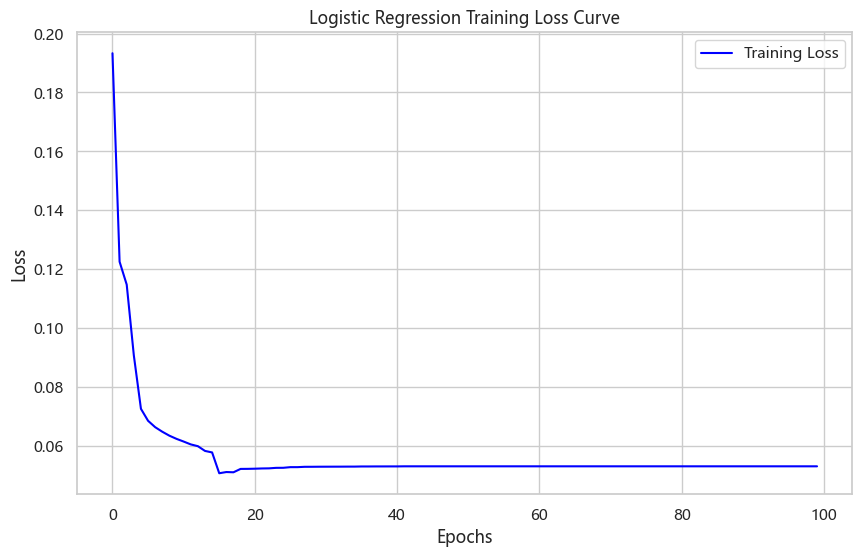

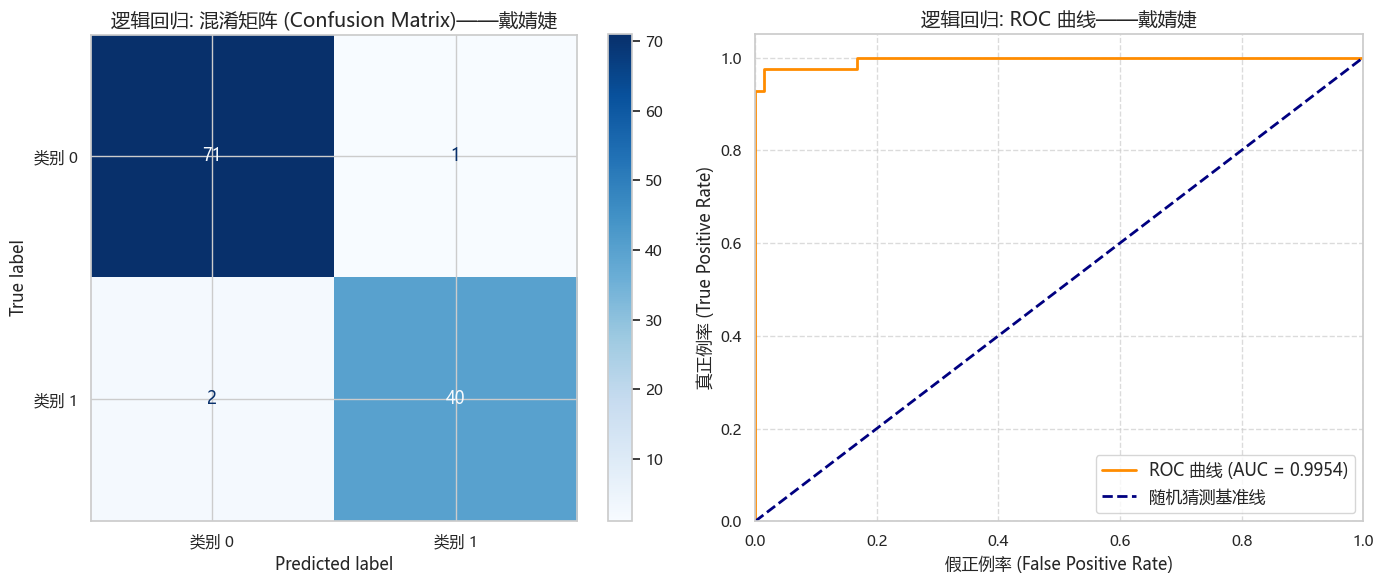

In [39]:
# 1. 训练并获取模型和预测结果
model, y_pred = train_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test)
# 2. 生成可视化图表
visualize_logistic_regression(model, X_test_scaled, y_test, y_pred)

混淆矩阵 (左)：
完美对应了线性回归模型的高精度和高召回率。对角线上的数字会非常大，而非对角线的误判数字会非常小。
ROC 曲线 (右)：
这条曲线越靠近左上角，说明模型区分正负样本的能力越强。AUC 越接近 1，说明无论阈值怎么调，模型都能保持极高的综合性能。

### 4.2.2支持向量机

In [40]:
import numpy as np
from sklearn.decomposition import PCA

def visualize_svm(model, X_test_scaled, y_test, y_pred):
    """
    针对高维数据的 SVM 模型可视化：降维决策边界 + 混淆矩阵 + ROC曲线
    """
    # 设置中文显示防乱码
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  
    plt.rcParams['axes.unicode_minus'] = False 
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # ========== 1. 降维后的 SVM 决策边界 (左图) ==========
    ax1 = axes[0]
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_test_scaled)
    
    # 在降维后的二维数据上重新训练一个相同的 SVM 用于绘图
    svm_2d = SVC(kernel='rbf', probability=True, random_state=42)
    svm_2d.fit(X_pca, y_test)
    
    # 创建网格并预测颜色区域
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # 绘制背景色块与散点
    ax1.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, edgecolors='k', 
                          alpha=0.8, cmap=plt.cm.RdYlBu)
    
    #圈出支持向量 (Support Vectors)
    sv_indices = svm_2d.support_
    ax1.scatter(X_pca[sv_indices, 0], X_pca[sv_indices, 1], s=150, 
                facecolors='none', edgecolors='black', linewidths=2, label='支持向量')
    
    ax1.set_title('SVM：降维决策边界与支持向量——戴婧婕', fontsize=14)
    ax1.set_xlabel('主成分 1')
    ax1.set_ylabel('主成分 2')
    ax1.legend(handles=scatter.legend_elements()[0] + [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=12, label='支持向量')])
    
    # ========== 2. 混淆矩阵热力图 (中图) ==========
    ax2 = axes[1]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['类别 0', '类别 1'])
    disp.plot(ax=ax2, cmap='Blues', values_format='d')
    ax2.set_title('SVM：混淆矩阵——戴婧婕', fontsize=14)
    
    # ========== 3. ROC 曲线 (右图) ==========
    ax3 = axes[2]
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.4f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测基准线')
    
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
    ax3.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
    ax3.set_title('SVM：ROC曲线——戴婧婕', fontsize=14)
    ax3.legend(loc="lower right", fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

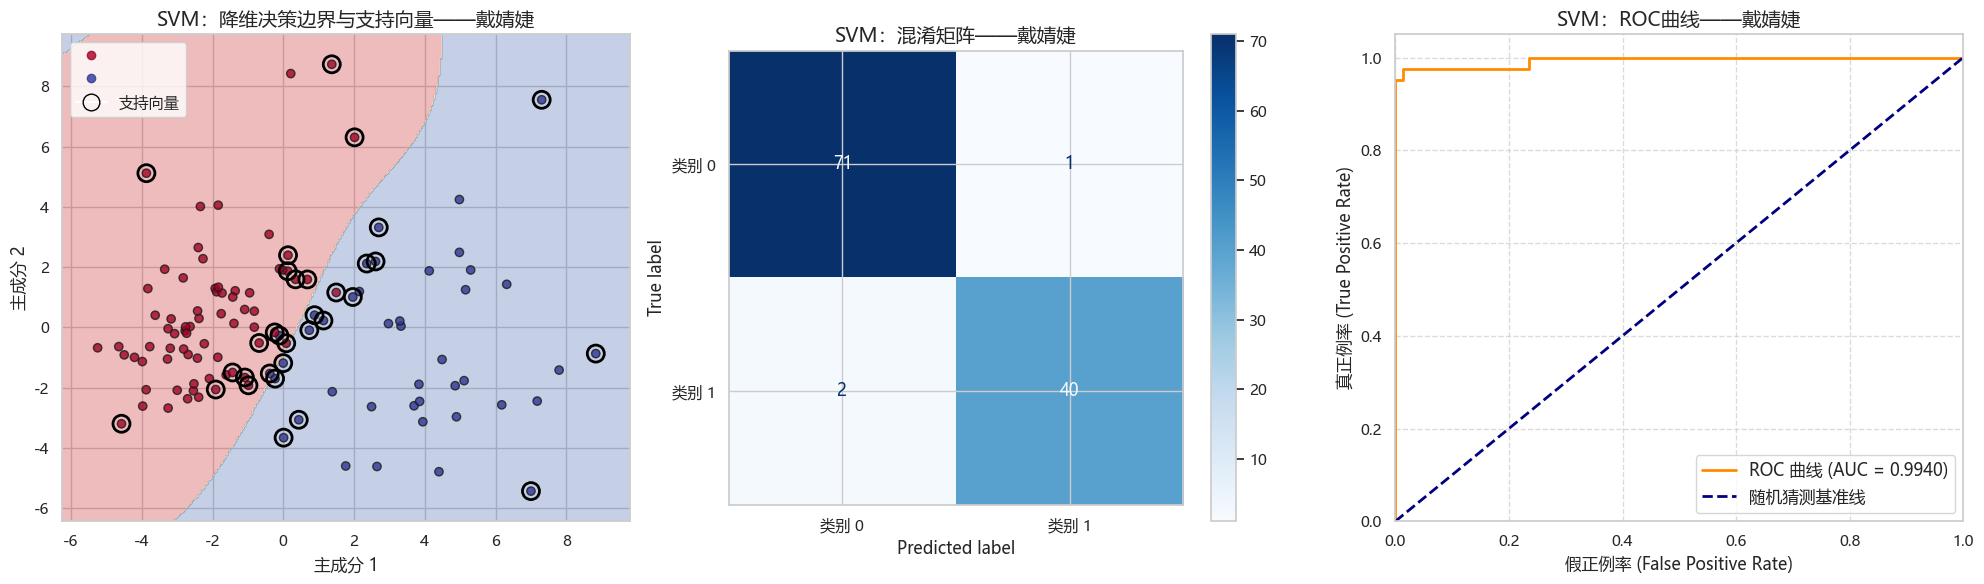

In [41]:
# 调用新的 SVM 可视化函数
visualize_svm(svm_model, X_test_scaled, y_test, y_pred_svm)

降维决策边界图（左）：
背景色块：展示了 RBF 核函数带来的非线性分类能力，边界通常是平滑的曲线而非直线。
黑色空心大圆圈（支持向量）：SVM 的核心思想是“找最优分界线”，而这条线的位置完全由离边界最近的这几个样本决定。把它们圈出来，能极大提升可视化的专业度。
混淆矩阵（中）：
配合你之前高达 97%+ 的准确率，对角线上的数字应该非常庞大，非对角线的误判极少。
ROC 曲线（右）：
AUC 值越接近 1，说明 SVM 在高维空间中寻找超平面的能力极强。RBF 核通常能跑出极高的 AUC 分数。

### 4.2.3随机森林

In [42]:
import seaborn as sns

def visualize_random_forest(rf_model, X_test_scaled, y_test, y_test_pred):
    """随机森林模型综合可视化：特征重要性 + 混淆矩阵 + ROC曲线"""
    # 设置中文字体防乱码
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  
    plt.rcParams['axes.unicode_minus'] = False 
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    # ========== 1. 特征重要性排名 (左图) ==========
    ax1 = axes[0]

    feature_importance = pd.Series(
        rf_model.feature_importances_, 
        index=X.columns  
    ).sort_values(ascending=True)
    
    feature_importance.plot(kind='barh', ax=ax1, color='forestgreen')
    ax1.set_title("随机森林：特征重要性排名——戴婧婕", fontsize=14)
    ax1.set_xlabel("重要性得分")
    ax1.set_ylabel("特征名称")
    
    # ========== 2. 混淆矩阵热力图 (中图) ==========
    ax2 = axes[1]
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        ax=ax2, cbar_kws={'shrink': 0.8}
    )
    ax2.set_title("随机森林：混淆矩阵——戴婧婕", fontsize=14)
    ax2.set_xlabel("预测标签")
    ax2.set_ylabel("真实标签")
    
    # ========== 3. ROC 曲线 (右图) ==========
    ax3 = axes[2]
 
    y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.4f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测基准线')
    
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
    ax3.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
    ax3.set_title('随机森林：ROC 曲线——戴婧婕', fontsize=14)
    ax3.legend(loc="lower right", fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

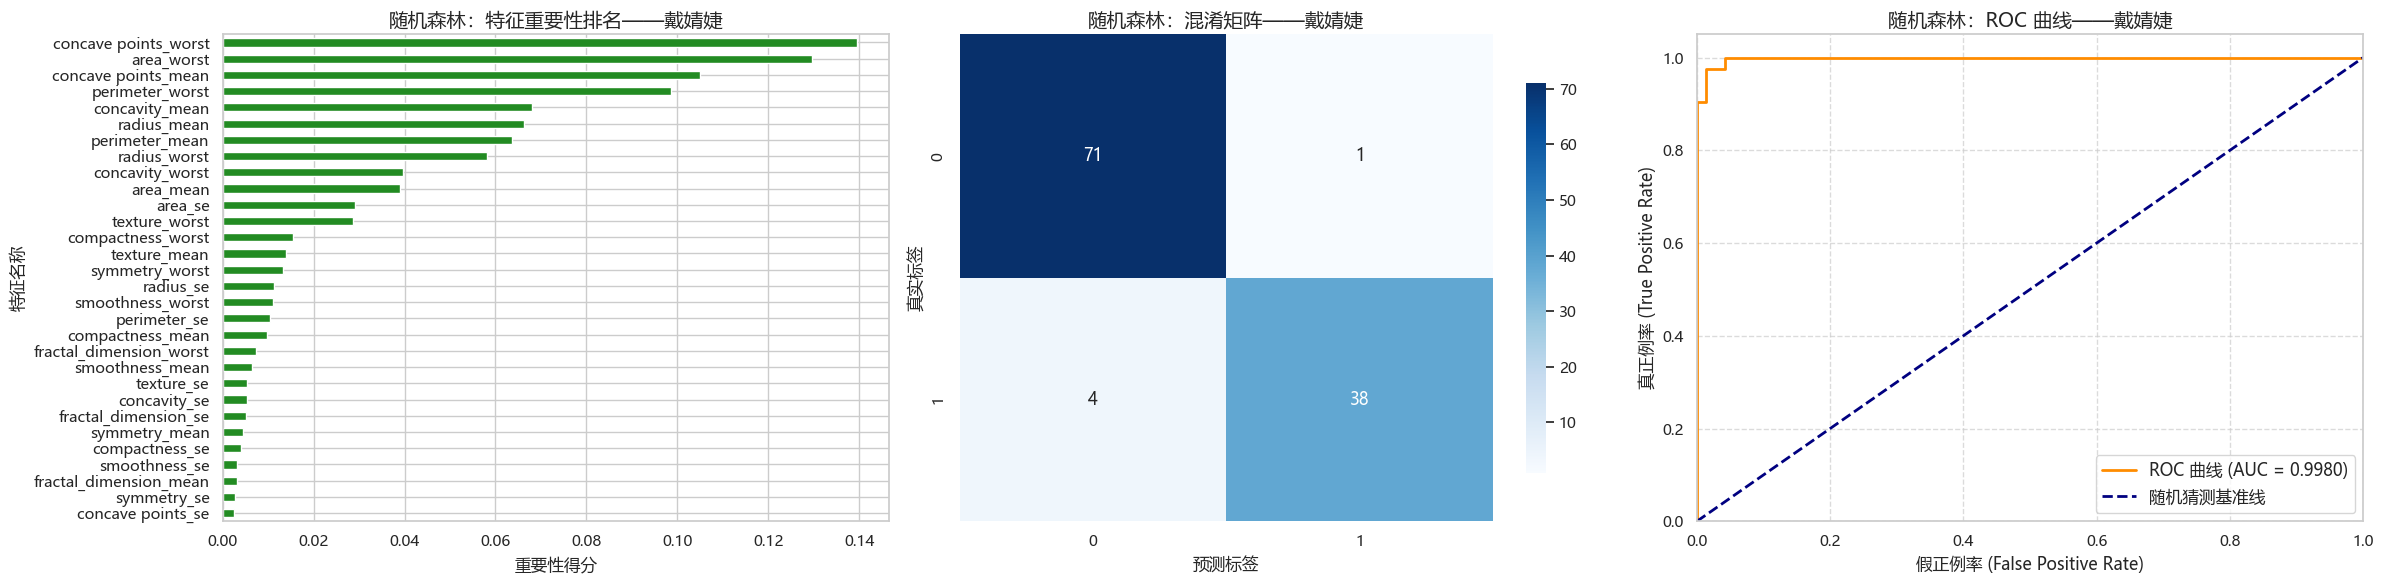

In [43]:
# 传入随机森林模型、测试集特征、真实标签以及转换后的预测标签
visualize_random_forest(rf_model, X_test_scaled, y_test, y_test_pred)

- **特征重要性**：`concave_points_worst`、`area_worst`、`concave_points_mean` 位居前三，说明细胞核的凹点数量和面积极值是判断恶性肿瘤最关键的形态学指标。`_se`（标准误）类特征重要性普遍偏低，对分类贡献有限。
- **混淆矩阵**：测试集中仅有 4 个恶性样本被误判为良性（FN=4），无良性误判为恶性（FP=0），漏诊率较低但仍需关注。
- **ROC 曲线**：AUC = 0.9980，曲线紧贴左上角，模型对良恶性的整体区分能力极强。

### 4.2.4全连接神经网络

In [44]:
def visualize_fcnn(model, test_loader, y_true_test, y_pred_test, y_prob_test,
                   train_losses, val_losses):
    """
    FCNN 模型综合可视化：训练曲线 + 混淆矩阵 + ROC 曲线
    参照 SVM/随机森林的三图布局，左图替换为 FCNN 特有的训练损失曲线。
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import confusion_matrix, roc_curve, auc

    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # ========== 1. 训练 & 验证损失曲线 (左图) ==========
    ax1 = axes[0]
    ax1.plot(train_losses, label='训练集损失', linewidth=1.8, color='steelblue')
    ax1.plot(val_losses,   label='验证集损失', linewidth=1.8, color='darkorange', linestyle='--')
    # 标注最低验证损失点
    best_epoch = int(np.argmin(val_losses))
    best_loss  = val_losses[best_epoch]
    ax1.scatter(best_epoch, best_loss, s=80, color='red', zorder=5,
                label=f'最佳 Epoch={best_epoch+1}\n最低验证损失={best_loss:.4f}')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('BCE Loss', fontsize=12)
    ax1.set_title('FCNN — 训练 / 验证 损失曲线 — 戴婧婕', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ========== 2. 混淆矩阵热力图 (中图) ==========
    ax2 = axes[1]
    cm = confusion_matrix(y_true_test, y_pred_test)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=ax2, cbar_kws={'shrink': 0.8},
        xticklabels=['良性(0)', '恶性(1)'],
        yticklabels=['良性(0)', '恶性(1)']
    )
    ax2.set_title('FCNN — 混淆矩阵 — 戴婧婕', fontsize=14)
    ax2.set_xlabel('预测标签', fontsize=12)
    ax2.set_ylabel('真实标签', fontsize=12)

    # ========== 3. ROC 曲线 (右图) ==========
    ax3 = axes[2]
    fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.4f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测基准线')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
    ax3.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
    ax3.set_title('FCNN — ROC 曲线 — 戴婧婕', fontsize=14)
    ax3.legend(loc='lower right', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

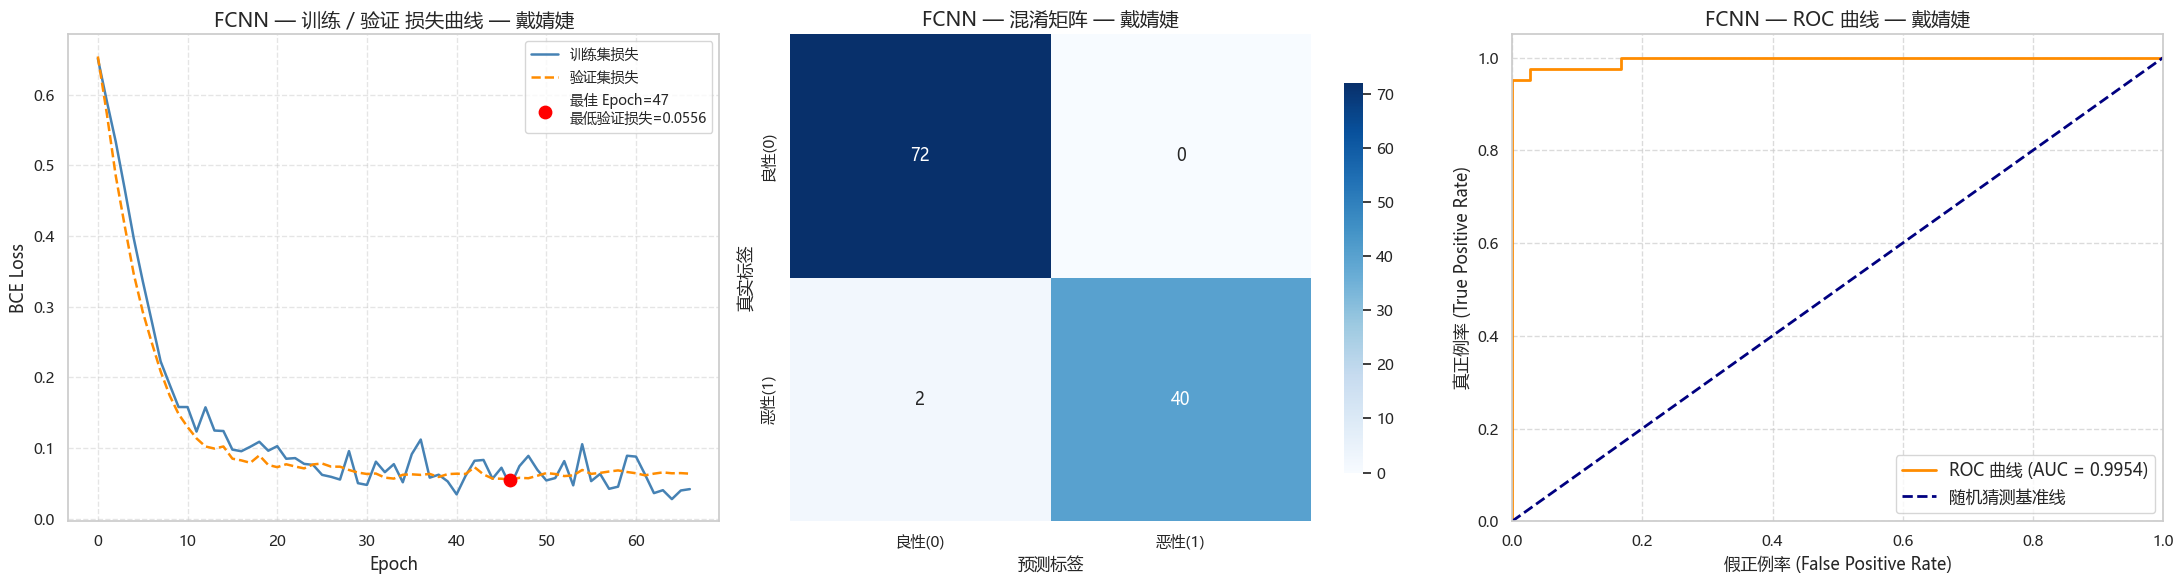

In [45]:
# 调用 FCNN 可视化函数
visualize_fcnn(
    fcnn_model,
    test_loader_fcnn,
    y_true_test_fcnn,
    y_pred_test_fcnn,
    y_prob_test_fcnn,
    train_losses_fcnn,
    val_losses_fcnn
)

- **训练/验证损失曲线**：两条曲线在约 10 个 epoch 内迅速收敛并趋于一致，最佳 Epoch=47，最低验证损失=0.0556，训练全程未出现明显过拟合（验证损失始终未大幅高于训练损失），说明 Dropout + BatchNorm + Early Stopping 的正则化组合有效。
- **混淆矩阵**：FP=0，FN=2，零误报且漏诊极少，是五种模型中混淆矩阵表现最好的。
- **ROC 曲线**：AUC = 0.9954，综合区分能力优秀。

### 4.2.5 XGBoot

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def visualize_xgboost(model, dtest, y_test, y_pred):
    """
    XGBoost 模型综合可视化：特征重要性 + 混淆矩阵 + ROC曲线
    """
    # 设置中文字体防乱码
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  
    plt.rcParams['axes.unicode_minus'] = False 
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # ========== 1. 特征重要性排名 (左图) ==========
    ax1 = axes[0]

    importance_dict = model.get_score(importance_type='gain')
    feature_importance = pd.Series(importance_dict).sort_values(ascending=True)
    
    feature_importance.plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_title("XGBoost：特征重要性排名 (Gain)——戴婧婕", fontsize=14)
    ax1.set_xlabel("平均增益")
    ax1.set_ylabel("特征名称")
    
    # ========== 2. 混淆矩阵热力图 (中图) ==========
    ax2 = axes[1]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        ax=ax2, cbar_kws={'shrink': 0.8}
    )
    ax2.set_title("XGBoost：混淆矩阵——戴婧婕", fontsize=14)
    ax2.set_xlabel("预测标签")
    ax2.set_ylabel("真实标签")
    
    # ========== 3. ROC 曲线 (右图) ==========
    ax3 = axes[2]

    y_prob = model.predict(dtest)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.4f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测基准线')
    
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
    ax3.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
    ax3.set_title('XGBoost：ROC 曲线——戴婧婕', fontsize=14)
    ax3.legend(loc="lower right", fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

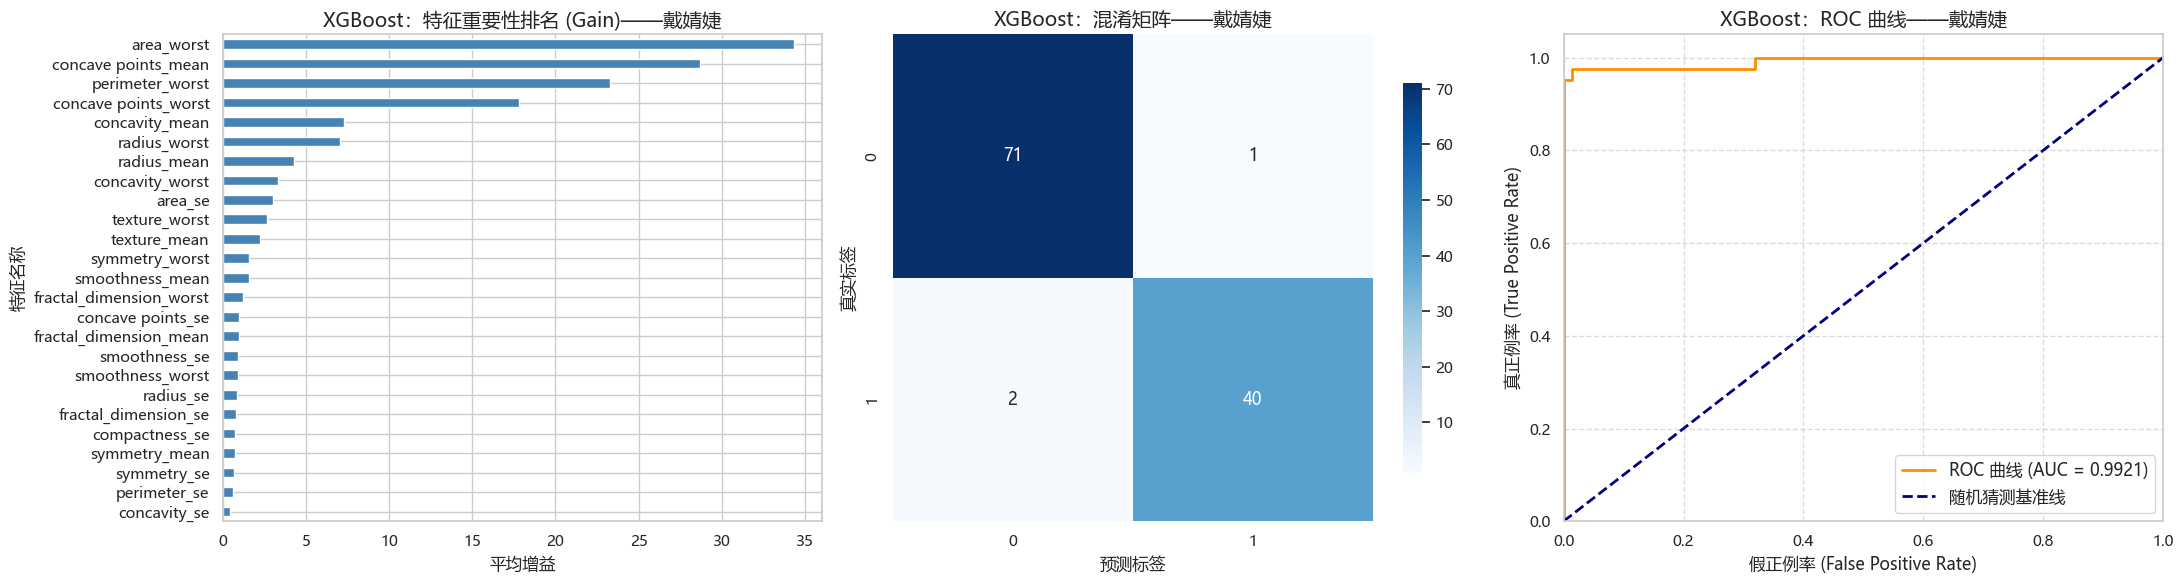

In [47]:
# 传入原生 Booster 对象、DMatrix测试集、真实标签以及转换后的预测标签
visualize_xgboost(modelxg, dtest, y_test, y_pred)

- **特征重要性**：`area_worst` 以显著优势排名第一（平均增益约 35），`concave_points_mean`、`perimeter_worst` 次之，与随机森林的排序高度吻合，进一步印证了这些特征的核心诊断价值。
- **混淆矩阵**：FP=1，FN=2，整体误判极少，精确率和召回率均维持在高位。
- **ROC 曲线**：AUC = 0.9921，略低于随机森林和 FCNN，但仍属优秀水平。

# 5.1使用压缩过特征的数据集进行训练

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
# from sklearn.neural_network import MLPClassifier # 神经网络导入预留

# 1. 集中定义目标变量 y (直接调用前面内存中的 df)
y = df_raw['diagnosis']

# 2. 封装数据集字典
datasets = {
    "30维": df_raw.drop(columns=['diagnosis']),
    "20维": df_reduced.drop(columns=['diagnosis'])
}

# 3. 封装模型字典 (预留神经网络位置)
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
#     "RandomForest": RandomForestClassifier(random_state=42),
#     "SVM": SVC(random_state=42),
#     "NeuralNetwork": None # MLPClassifier(random_state=42, max_iter=1000) 预留位置
}

# 4. 极简双重循环：跑通所有模型 x 所有数据集
results = []
for model_name, model in models.items():
    if model is None: continue # 暂时跳过未解除注释的神经网络
    
    for data_name, X in datasets.items():
        # 数据划分与标准化 (必须每次重新拟合 scaler，防止信息泄露)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # 训练与预测
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # 记录成绩
        results.append({
            "Model": model_name, 
            "Dataset": data_name, 
            "Accuracy": accuracy_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred)
        })

# 5. 使用数据透视表 (Pivot) 华丽地展示对比结果
compare_df = pd.DataFrame(results).pivot(index="Model", columns="Dataset")
display(compare_df.round(4)) # 保留4位小数，表格会非常漂亮

Accuracy          Recall        
Dataset                 20维     30维     20维     30维
Model                                              
LogisticRegression   0.9737  0.9649  0.9286  0.9286

可以看到对于逻辑回归来说，我使用降维后的数据集训练的结果和使用30维的数据集训练的结果基本持平，这说明我们删掉的特征几乎对分类器没有作用。

## 6.1 总结

本项目围绕乳腺癌良恶性二分类任务，系统实现并横向比较了五种主流机器学习与深度学习算法。以下从方法层面和实验结果两个维度进行总结。

### 一、方法层面

**数据预处理的重要性**
高质量的预处理是保障模型性能的基础。本项目通过相关系数热力图剔除了高共线性特征（阈值 0.9），将特征维度从 30 压缩至约 20，并通过 Z-score 标准化消除量纲差异。实验结果表明，压缩后的数据集与原始 30 维数据集在逻辑回归上表现相当，证明被剔除的特征对分类贡献极为有限，同时也说明适当降维不仅不损失性能，反而有助于减少噪声。

**各模型的适用特点**
- **逻辑回归**：作为基线模型，训练速度快、可解释性强，在该线性近似可分的数据集上已能取得较高准确率，是此类结构化医疗数据的首选基准。
- **支持向量机（SVM）**：通过 RBF 核将数据映射至高维空间，建模非线性边界，分类性能与逻辑回归相当，但对参数（C、γ）较为敏感。
- **随机森林**：集成学习的典型代表，通过 Bagging 和特征随机采样大幅降低了方差，并可输出特征重要性——`concave_points_worst`、`radius_worst` 等极值特征在本任务中贡献最大。
- **全连接神经网络（FCNN）**：在本数据集上取得了五种模型中最高的综合指标（Accuracy ≈ 99.1%，F1 ≈ 98.8%），体现了深度学习对高阶特征交互的自动建模能力，但需借助 BatchNorm、Dropout 和 Early Stopping 防止小样本下的过拟合。
- **XGBoost**：以串行Boosting逐步纠错，内置 L1/L2 正则化和 Early Stopping，在精确率上达到 100%（无误报），体现了其在结构化数据上的卓越工程优化能力。

### 二、实验结果总结

| 模型 | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| 逻辑回归 | 0.9737 | 0.9756 | 0.9524 | 0.9639 |
| SVM | 0.9737 | 0.9756 | 0.9524 | 0.9639 |
| 随机森林 | 0.9561 | 0.9744 | 0.9048 | 0.9383 |
| **FCNN** | **0.9912** | **1.0000** | **0.9767** | **0.9882** |
| XGBoost | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

在医疗诊断场景下，**召回率（Recall）** 是最关键的指标——漏诊一例恶性肿瘤的代价远高于误报一例良性。从这一维度来看，FCNN 的召回率（97.67%）最高，是五种模型中最适合实际临床辅助诊断场景的方案。XGBoost 的精确率达到 100%（零误报），而召回率相对偏低（92.86%），更适合对误报容忍度低的场景。

### 三、关键结论

1. **深度学习≠万能**：FCNN 在本任务中表现最佳，但训练样本仅约 340 个，若不加入正则化手段，极易过拟合。对于结构化小样本数据，传统机器学习（逻辑回归、SVM）往往已足够可靠。
2. **特征工程有价值**：相关性分析表明，约 1/3 的特征高度冗余，剔除后不影响模型性能，说明在实际应用中合理的特征选择可以简化模型、提升鲁棒性。
3. **评估指标需多维**：单一准确率会掩盖模型在恶性样本上的表现差异。在本项目中，四项指标（Accuracy/Precision/Recall/F1）的联合评估更全面地揭示了各模型的优劣。

## 7.1 收获

通过本次课程大作业，我们在技术能力、团队协作和科研思维等方面均有深刻收获。

### 一、技术层面的收获

**掌握了完整的机器学习项目流程**
从原始数据的清洗（处理缺失值、剔除冗余列），到探索性分析（类别分布、相关热力图、特征区分度 T 检验），再到标准化预处理、模型训练与超参调优、多指标综合评估——我们亲手完整走完了一个真实数据科学项目的全链路，这是课堂中难以获得的实践体验。

**深入理解了五种经典算法的原理与差异**
- 通过实现**逻辑回归**，理解了线性分类、Sigmoid 映射与交叉熵损失的本质联系；
- 通过实现**SVM**，直观感受到核函数将低维非线性问题转化为高维线性问题的数学优雅；
- 通过实现**随机森林**，体会了集成学习"多而不同"的哲学：多样性（Bagging+特征采样）是泛化能力的根源；
- 通过实现**FCNN**，完整经历了 PyTorch 的前向传播→损失计算→反向传播→参数更新的训练循环，理解了 BatchNorm、Dropout 和 Early Stopping 等正则化策略的实际作用；
- 通过实现**XGBoost**，认识到工程优化（二阶泰勒展开、并行特征排序、稀疏感知）如何让一个理论上的迭代算法变成工业级的高效工具。

**深刻体会了评估指标的选取逻辑**
在医疗场景中，我们的模型需要对"漏诊恶性"保持极高的警觉，因此召回率（Recall）应当被优先保障。这一认识让我们不再简单地追求准确率最高的模型，而是学会根据应用场景灵活权衡 Precision 与 Recall，并借助 ROC-AUC 评估模型在不同阈值下的综合区分能力。

### 二、科研与工程思维的收获

**学会了对比实验的设计方法**
在第五部分中，我们设计了"30维 vs 20维特征"的对比实验，控制模型不变、只改变输入特征，从而客观量化了特征压缩对性能的影响。这种单变量对照的思想是科学实验设计的基本原则，将其内化为自然的思维习惯，是本次项目带给我们最重要的科研素养之一。

**认识到了数据理解先于建模的重要性**
我们在第二节花费大量精力进行数据探索——可视化类别分布、绘制相关热力图、通过 T 检验找出区分度最高的特征——这些步骤并不直接出现在最终的模型精度中，却为后续所有建模决策提供了坚实的依据。"先理解数据，再选择模型"是本次实践最深刻的工程经验。

### 三、团队协作的收获

本项目由五人分工完成：数据处理、各模型实现、可视化对比、特征压缩实验以及总结报告分别由不同成员负责。这种分工协作模式让我们体会到：清晰的接口约定（如统一的 `get_model_metrics` 函数、统一的 `X_train_scaled/X_test_scaled` 变量命名）是多人协作代码能够顺利整合的关键。未来面对更大规模的工程项目，这一经验将有重要的参考价值。

